In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os, sys, alive_progress

from quantum_electron.electron_counter import FullModel, make_potential, find_minimum_location
from quantum_electron.schrodinger_solver import QuantumAnalysis
from quantum_electron.utils import xy2r, r2xy, crop_potential, find_nearest,  density_from_positions, select_outer_electrons, find_minimum_location

from zeroheliumkit.src.importing import Reader_DXF
from zeroheliumkit.fem import FieldAnalyzer
from zeroheliumkit.src.settings import *
import matplotlib.animation as animation

%matplotlib inline
%config InlineBackend.figure_format='retina'

plot_config = {"anchors": CYAN,
               "0": BLUE,
               "EBEAMLITHO_GUARDS": ORANGE,
               "EBEAMLITHO_SMALLPADS": RED,
               "Pillar0": GREEN}
import zeroheliumkit 
from scipy.constants import elementary_charge as qe, epsilon_0 as eps0, electron_mass as me, Boltzmann as kB
from matplotlib import patheffects as pe
import random


## Download the potential

./sim2/sample_resevoir_10x10_no_bond_lines.dxf // Layers : dict_keys(['EBEAMLITHO_SMALLPADS', '0', 'EBEAMLITHO_GUARDS'])


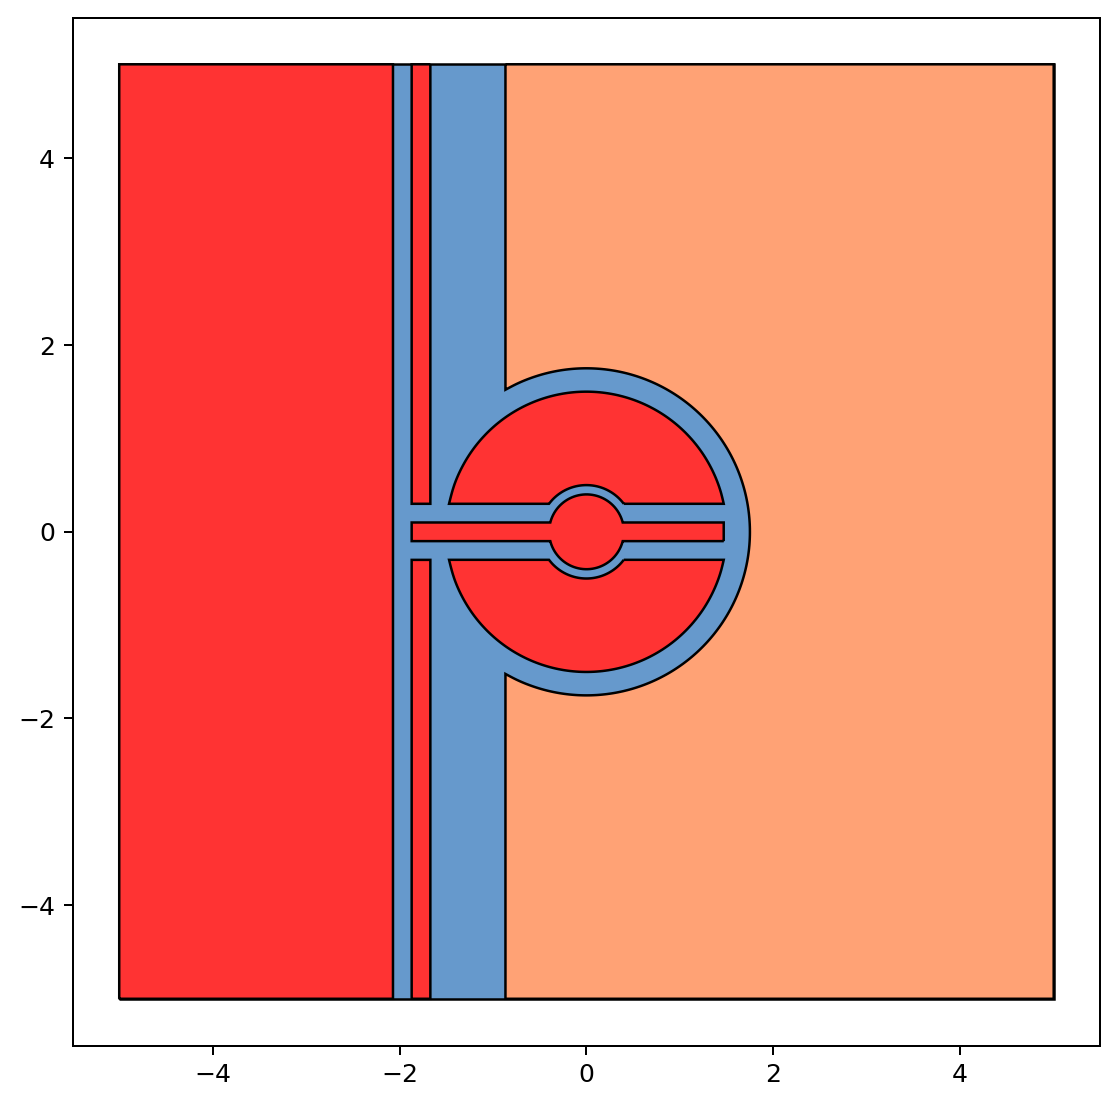

In [2]:
dirname = 'sim_test/'
device = zeroheliumkit.GeomCollection(layers=Reader_DXF(r"./sim2/sample_resevoir_10x10_no_bond_lines.dxf").geometries)
device.quickplot(plot_config)
trap = FieldAnalyzer((dirname+'phi_xy.txt', 'dot', '2Dmap'))


In [23]:

print(f"Input data dx = {np.diff(trap.dot['xlist'])[0] * 1e3:.1f} nm")
print(f"Input data dy = {np.diff(trap.dot['ylist'])[0] * 1e3:.1f} nm")


Input data dx = 20.0 nm
Input data dy = 20.0 nm


## Choose the voltages
typical charge noise 100 uV (GaAs @Delft) 230 uV(Si @Delft) 70 uV (best Si) 8 uV (best GaAs) 

These values are dominated by the devices themselves, not from the electronics.

In [35]:
from quantum_electron.utils import crop_potential

voltages = {
    'half_donut_top':0.5,
    'half_donut_bottom':0.5,
    'gate_top':0.2,
    'gate_bottom':0.2,
    'reservoir':0.7,
    'center':0.6,
    'guard':-0.000,
}

for electrode in trap.dot.keys():
    if electrode == 'xlist' or electrode == 'ylist':
        break
    new_x, new_y, new_U = crop_potential(x=trap.dot['xlist'], y=trap.dot['ylist'], U=trap.dot[electrode],
                                         xrange=(-5, 2), yrange=(-4,4))

    trap.dot[electrode] = new_U

trap.dot['xlist'] = new_x
trap.dot['ylist'] = new_y

(-5.0, 2.0)

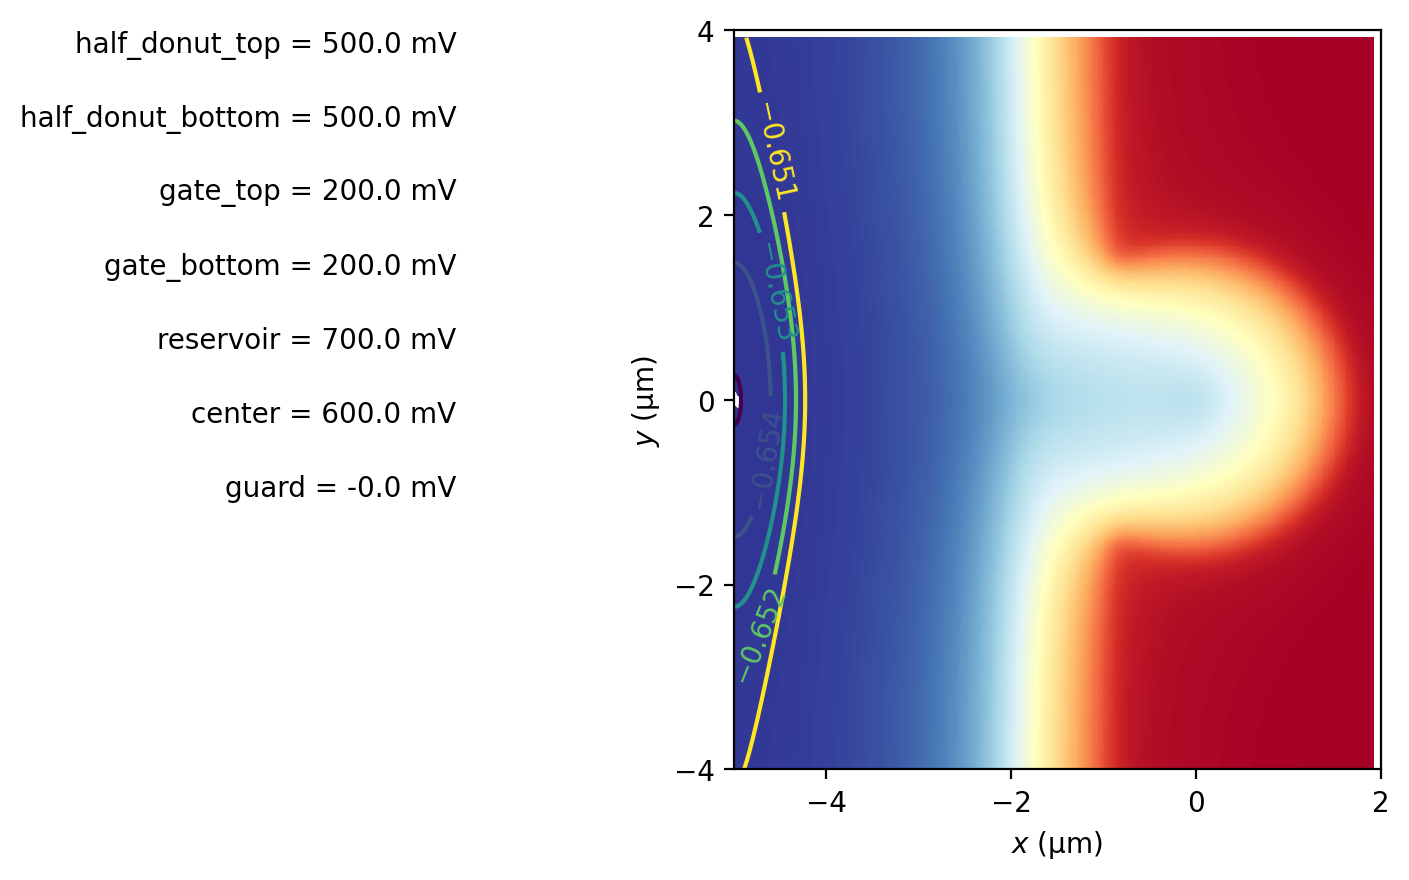

In [36]:

fig, ax = plt.subplots()
fm = FullModel(trap.dot, voltages)
fm.plot_potential_energy(ax=ax, coor=[0,0], dxdy=(10, 8))
ax.set_xlim(-5, 2)


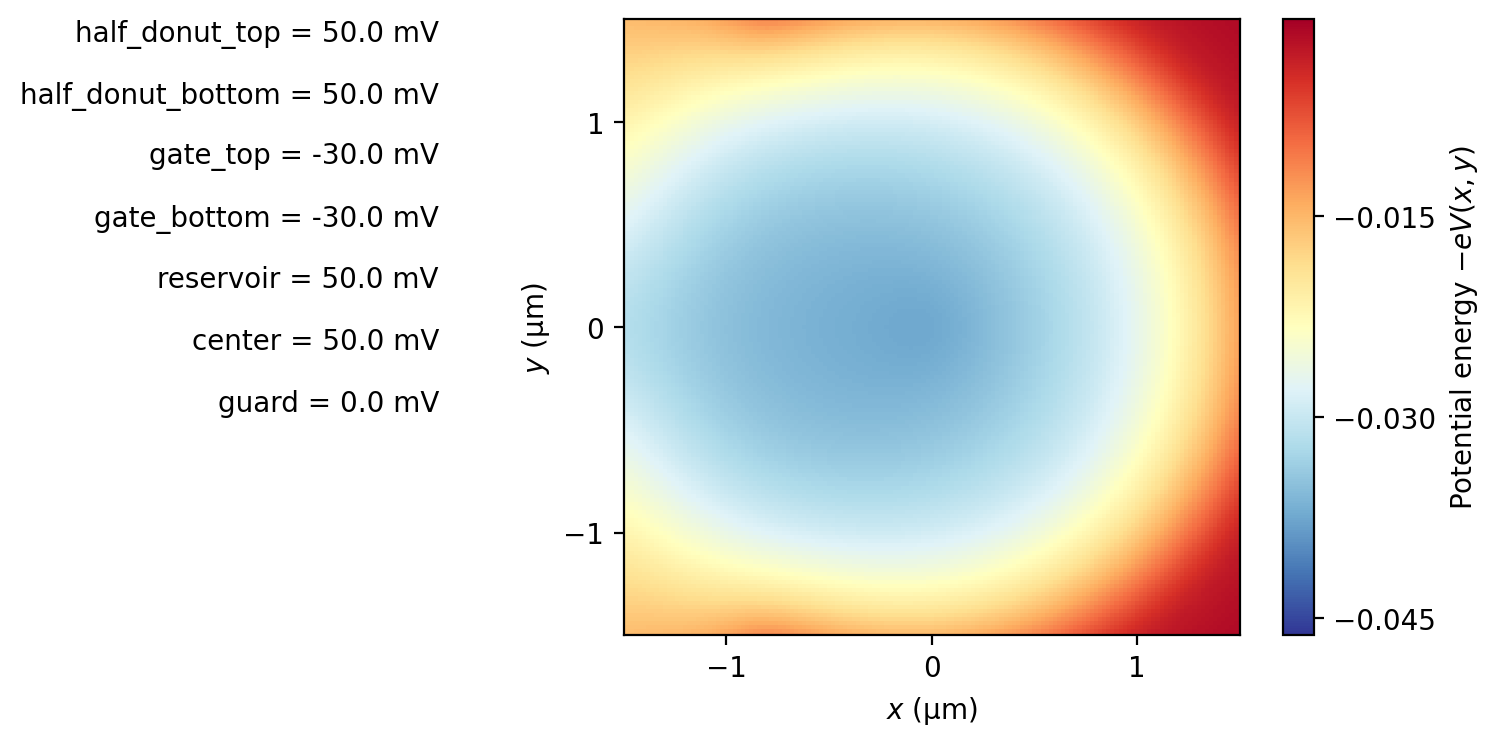

In [81]:
qa = QuantumAnalysis(trap.dot, voltages)

qa.plot_potential_energy(coor=(0, 0), dxdy=(3, 3))


max_ysol:1.45
y_com_max:0.4991906832677109
max_ysol:1.45
y_com_max:0.49917040250117267
max_ysol:1.45
y_com_max:0.4991565579248454
max_ysol:1.45
y_com_max:0.4991220635349275
max_ysol:1.45
y_com_max:0.4991455797494
max_ysol:1.45
y_com_max:0.4990822363956539


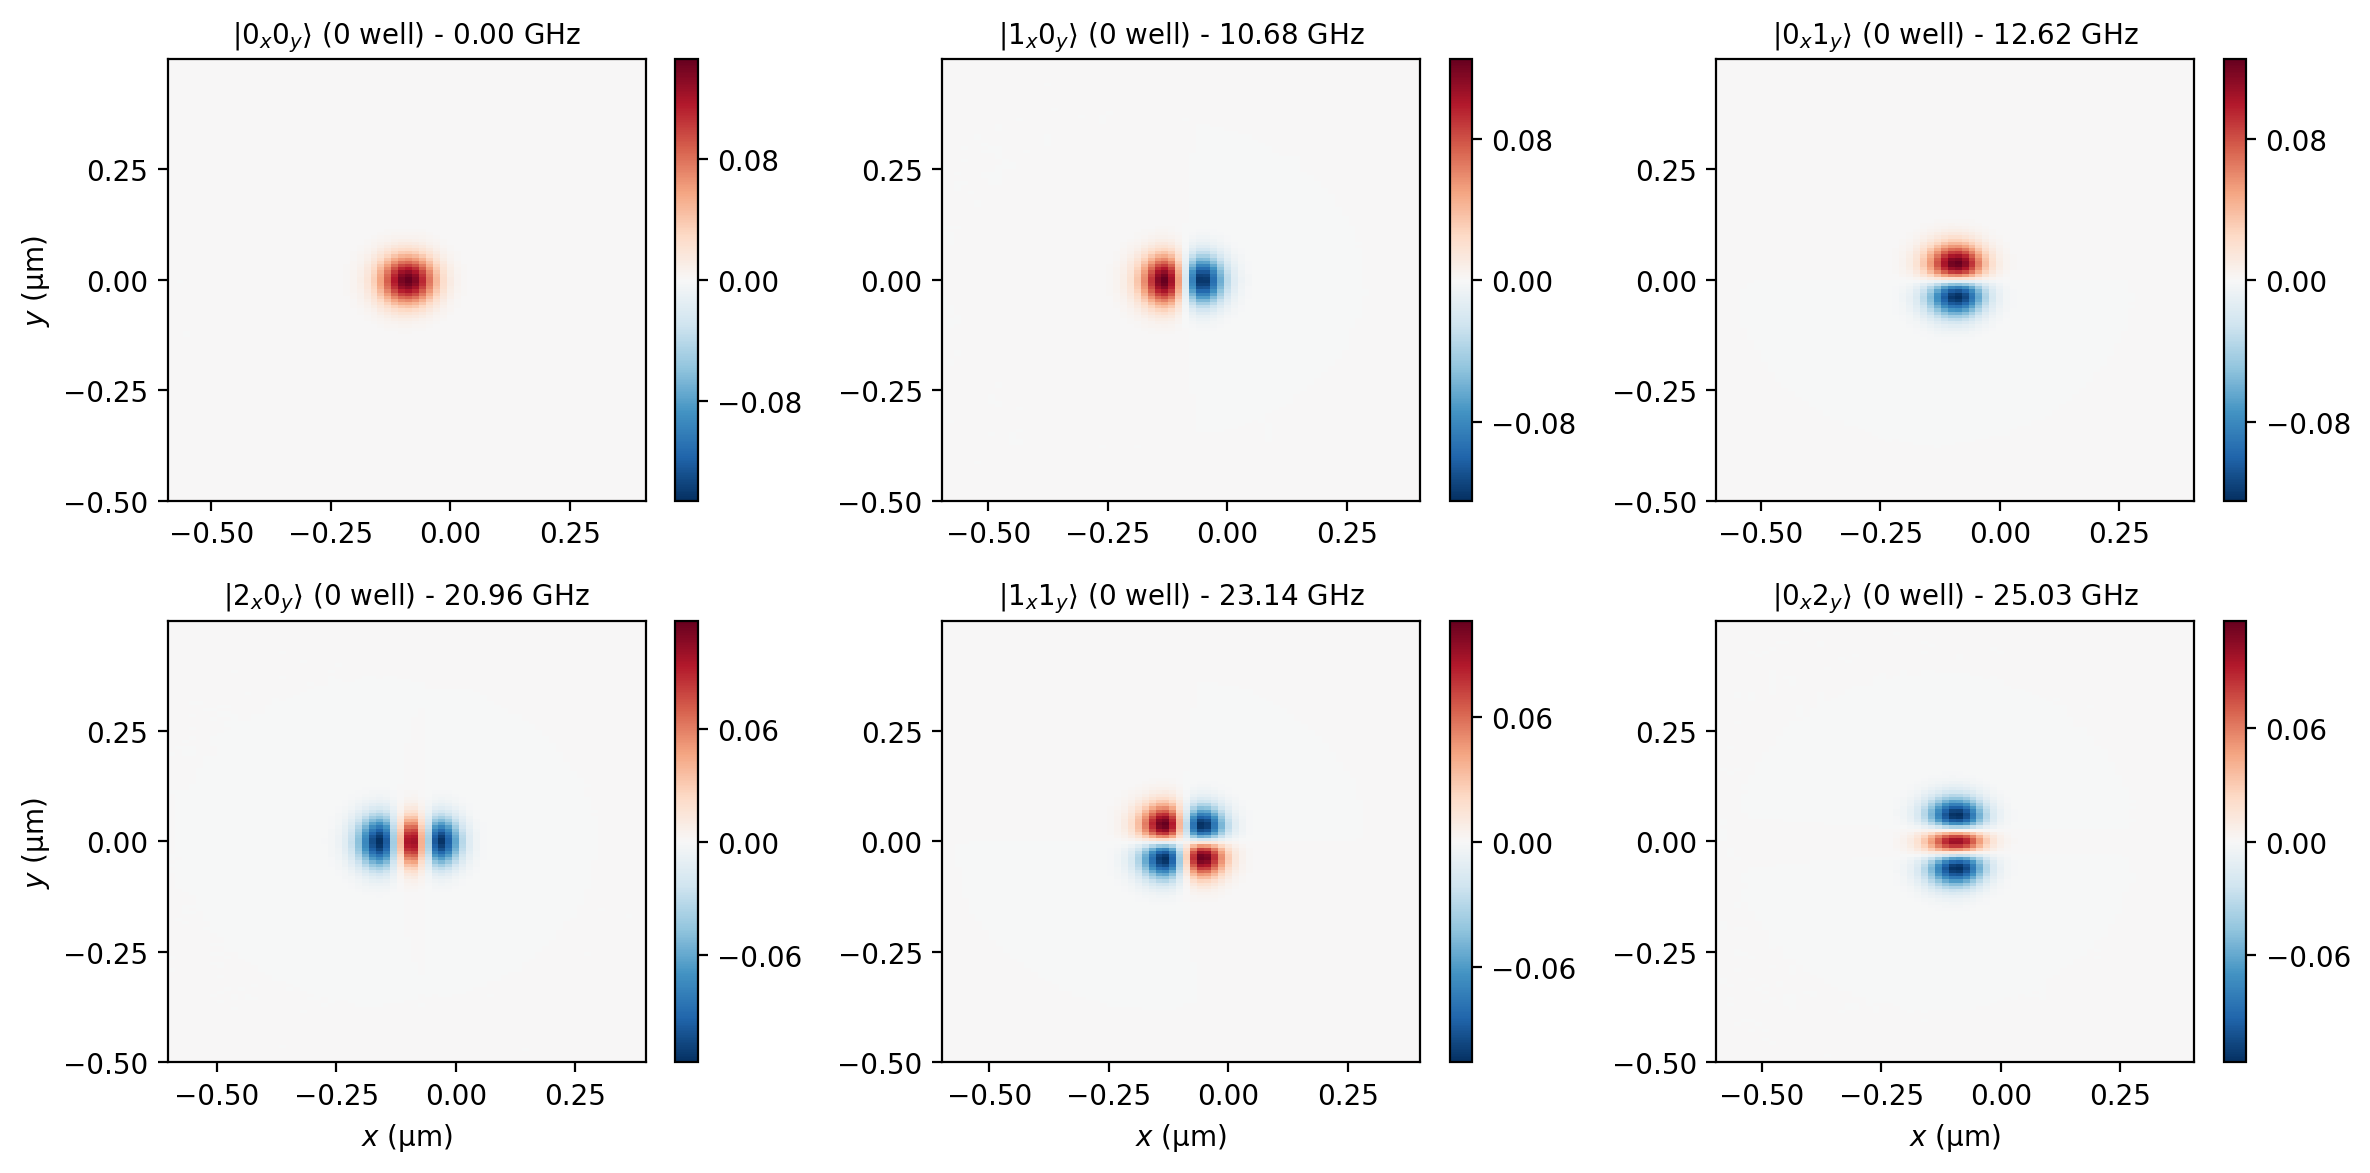

In [ ]:
 #Returns the frequencies of the first N=6 eigenmodes for a single electron trapped in a potential. 
single_electron_frequencies = qa.get_quantum_spectrum(coor=(0, 0), dxdy=(1, 0.5), plot_wavefunctions=True, n_x=201, n_y=201)
# here the energy splitting between first and excited is higher than with the same script on box because the S. equation is solved on a larger interval

## Test voltage configuration

### Calculate electrons equilibrium positions

Not converged after 500000 steps.
1.8485627193020092e-07
The distance between the last two iterations is 0.04 um.
There are 0 electrons in the dot.


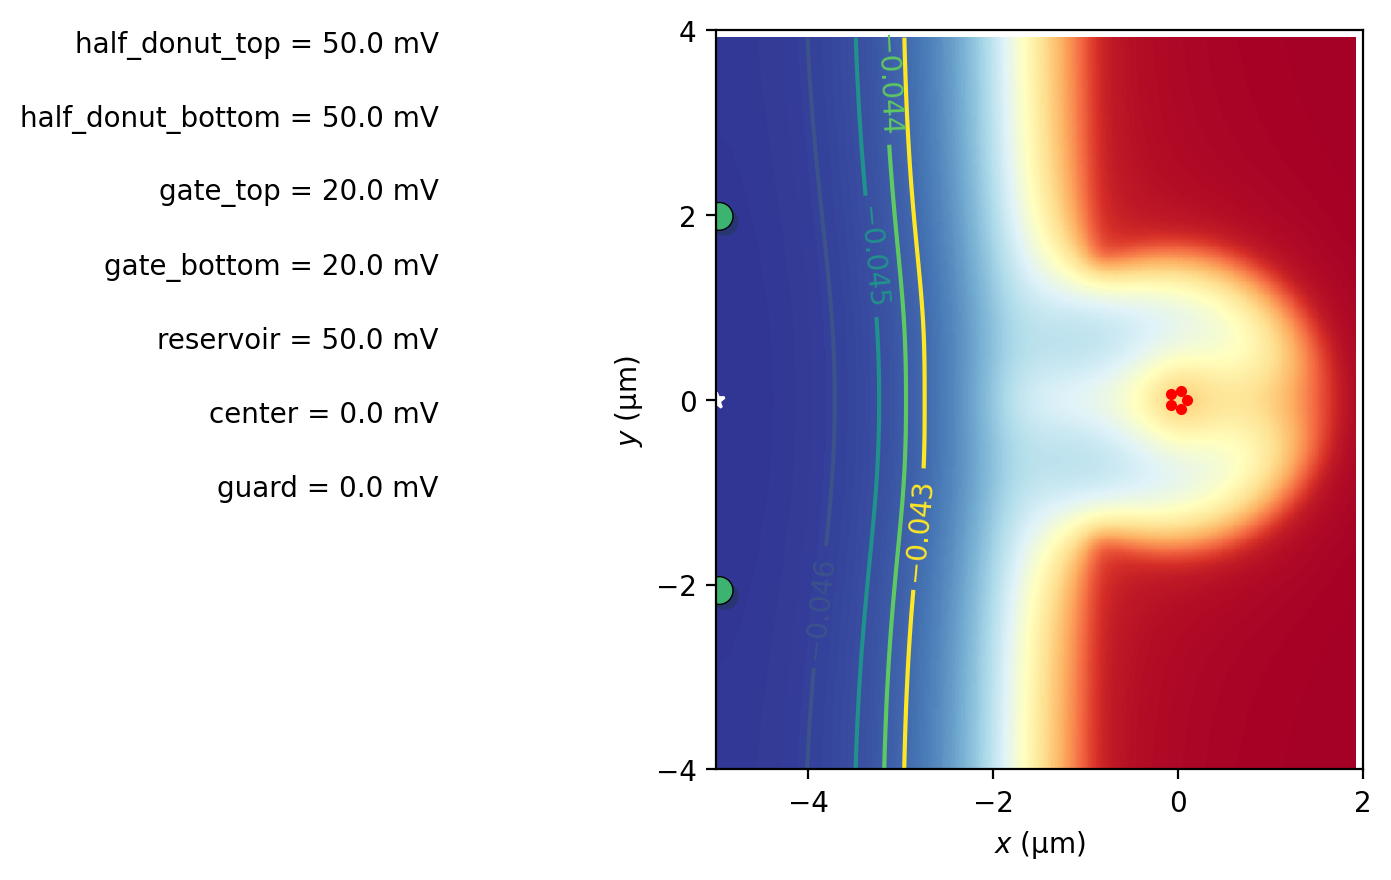

In [37]:
import numpy as np
import matplotlib.pyplot as plt

# Conversion en float64 des bornes
x_min = np.float64(np.min(trap.dot['xlist']) * 1e-6)
x_max = np.float64(np.max(trap.dot['xlist']) * 1e-6)
y_min = np.float64(np.min(trap.dot['ylist']) * 1e-6)
y_max = np.float64(np.max(trap.dot['ylist']) * 1e-6)

voltages = {
    'half_donut_top':0.05,
    'half_donut_bottom':0.05,
    'gate_top':0.02,
    'gate_bottom':0.02,
    'reservoir':0.05,
    'center':0,
    'guard':0.000,
}

options = { "include_screening" : False, # Include screening of electron-electron interactions due to thin film.
           "screening_length" : np.inf, # Typically helium thickness.
           "potential_smoothing" : 1e-5, # Numerical smoothing of the splines (gets rid of some noise, can introduce artifacts)
           "remove_unbound_electrons" : False, # Removes electrons if they shot outside the solution box.
           "remove_bounds" : None, # Sets which electrons should be removed if above is True.
           "trap_annealing_steps" : [0.1] * 10, # List of annealing temperatures, length determines the number of steps
           "max_x_displacement" : 0.1e-6, # Maximum x-displacement of solved electron positions during annealing.
           "max_y_displacement" : 0.1e-6} # Maximum y-displacement of solved electron positions during annealing.


plot_initial_condition = True
convergence_method = 'Physical gradient descent'
Nmax = 5
energies = np.zeros(Nmax-1, dtype=np.float64)
max_force = []


# Dimensionless rescaling
# -------------------------
# Base units (SI → dimensionless)
L0 = 1e-6                      # 1 μm in meters
E0 = qe                        # 1 eV in joules
M0 = me                        # electron mass in kg
Q0 = qe                        # elementary charge in C
T0 = L0 * np.sqrt(M0/E0)      # derived time unit

# Convert your physical timestep into dimensionless dt
dt_phys = 1e-13                # your original dt in seconds
dt = np.float64(dt_phys / T0)  # dimensionless

# Now redefine your usual Verlet coefficients in *this* dt
gamma    = np.float64(-0.01) / dt
prefactor= np.float64(1.0) / (1.0/dt**2 - gamma/dt)
A        = np.float64(2.0/dt**2 - gamma/dt)
B        = np.float64(1.0/dt**2)

max_timesteps = 500000# Maximum number of timesteps for the convergence method


for N in [5]:
    f = FullModel(trap.dot, voltages, **options)
    f.remove_unbound_electrons = False

    initial_condition = f.generate_initial_condition(N, center=[0, 0], radius=np.float64(0.1e-6))
    init_x, init_y = r2xy(initial_condition)

    if convergence_method == 'L-BFGS-B':
        f.trap_annealing_steps = [0.5] * 30
        res = f.get_electron_positions(n_electrons=N, electron_initial_positions=initial_condition,
                                       verbose=False, gradient_tolerance=1e-9, ftol=1e-300)
        equilibrium_positions = res['x']

    elif convergence_method == 'Physical gradient descent':
        # Convert the *physical* positions into primed coords:
        r_old = (initial_condition / L0).astype(np.float64)
        r_cur = r_old.copy()
        j = 2

        while True:
            # 1) compute physical gradient at r_phys = r_cur*L0
            grad_phys = f.grad_total(r_cur * L0)          # in V/m
            # 2) F_phys = -qe * grad_phys (J/m), convert to dimensionless:
            F = -(qe * grad_phys) * (L0/E0)     # dimensionless
            max_force.append(np.max(np.abs(F)))

            # 3) Verlet‐damped update (dimensionless)
            r_next = prefactor * (F + r_cur * A - r_old * B)

            # 4) Remove electrons out of domain in primed coords
            x_next = r_next[::2];  y_next = r_next[1::2]
            inside = np.logical_and.reduce((
                x_next*L0 >= x_min, x_next*L0 <= x_max,
                y_next*L0 >= y_min, y_next*L0 <= y_max
            ))


            r_next_filtered    = np.empty((2*np.sum(inside)), dtype=np.float64)
            r_current_filtered = np.empty((2*np.sum(inside)), dtype=np.float64)

            r_next_filtered[::2]    = x_next[inside]
            r_next_filtered[1::2]   = y_next[inside]
            r_current_filtered[::2] = r_cur[::2][inside]
            r_current_filtered[1::2]= r_cur[1::2][inside]

            # rotate for next pass
            r_old, r_cur = r_current_filtered, r_next_filtered
            j += 1

            if len(r_cur)==0:
                print(f'During the convergence, no electrons left after {j} steps.')
                break
            
            # 5) Check convergence in dimensionless force
            if np.max(np.abs(F)) < 1e-12:
                print(f'Converged after {j} steps.')
                r_cur = r_next_filtered
                break

            if j >= max_timesteps:
                print(f'Not converged after {max_timesteps} steps.')
                break

        # Convert *back* to physical coordinates (meters)
        equilibrium_positions = (r_cur * L0)
        print(max_force[-1])



    print(f'The distance between the last two iterations is {np.linalg.norm(r_cur - r_old) * 1e6:.2f} um.')

    final_x, final_y = r2xy(equilibrium_positions)
    number_electron = f.count_electrons_in_dot(equilibrium_positions,
                                               trap_bounds_x=(-2e-6, 2e-6),
                                               trap_bounds_y=(-2e-6, 2e-6))
    print(f'There are {number_electron} electrons in the dot.')

    fig, ax = plt.subplots()
    f.plot_potential_energy(coor=[0, 0], dxdy=(10, 8), ax=ax)
    res = {'x': equilibrium_positions}
    f.plot_electron_positions(res)
    ax.set_xlim(-5, 2)

    if plot_initial_condition:
        plt.plot(init_x * 1e6, init_y * 1e6, 'or', ms=3)





Electron positions: x_min=-5.00e-06, x_max=1.98e-06, y_min=-4.00e-06, y_max=3.98e-06
2.220446049250313e-16


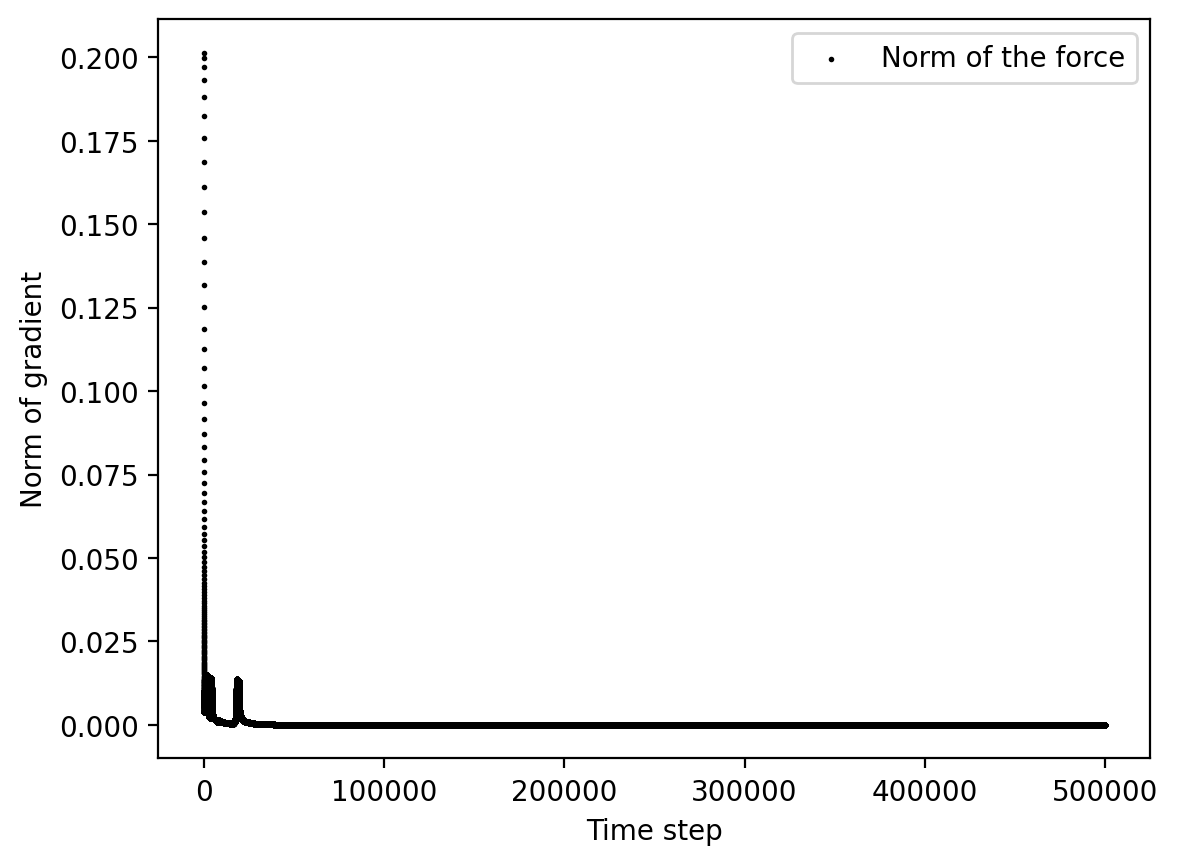

In [27]:
fig, ax = plt.subplots()
ax.scatter(range(len(max_force)), max_force, s=1, c='k', label='Norm of the force')
ax.set_xlabel('Time step')
ax.set_ylabel('Norm of gradient')
# ax.set_ylim(0, 3e-13)
ax.legend()

print(f"Electron positions: x_min={x_min:.2e}, x_max={x_max:.2e}, y_min={y_min:.2e}, y_max={y_max:.2e}")
if np.any(final_x < x_min) or np.any(final_x > x_max) or np.any(final_y < y_min) or np.any(final_y > y_max):
    print("Electron outside potential grid!")

print(np.finfo(np.float64).eps)


### Setup EOM

In [38]:
Vrms = 140e-9
f0 = 0.8e9

Z = 2 / 1.055e-34 * (Vrms / (2 * np.pi * f0)) ** 2

resonator_dict = {"f0" : f0, # Resonance frequency for the resonator (only used for solving motional frequencies)
                  "Z0" : Z} # Resonator impedance (only used for solving motional frequencies)


In [49]:
f.set_rf_interpolator(rf_electrode_labels=['center'])
# solves the equations of motion  
K, M = f.setup_eom(res['x'], resonator_dict=resonator_dict)
# added: resonator_dict=resonator_dict
eigenfrequencies, evecs = f.solve_eom(K, M, sort_by_cavity_participation=True, filter_nan=True)
print(f"Eigenfrequencies: {eigenfrequencies}")

Eigenfrequencies: [8.00000000e+08 6.45603240e+08 1.73802785e+08 2.27263269e+09
 2.22919337e+09]


### AC electric field

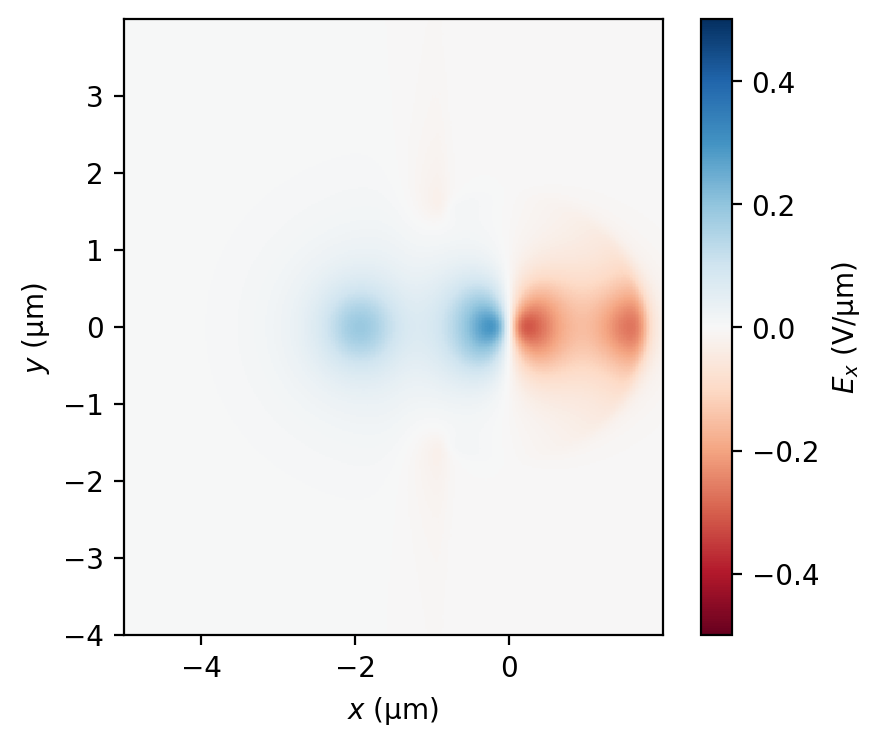

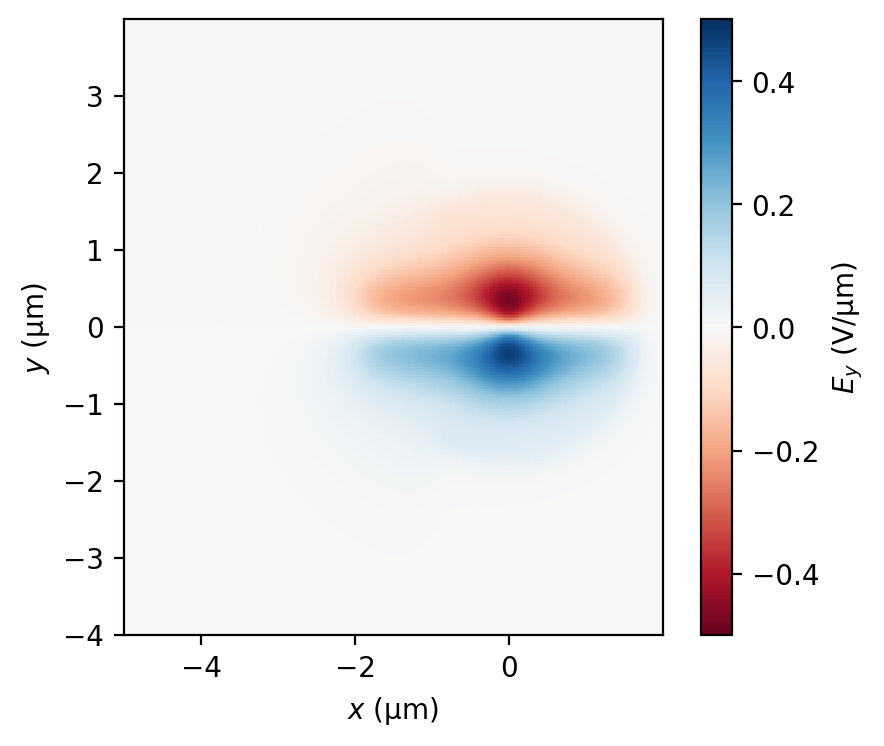

In [32]:
X, Y = np.meshgrid(trap.dot['xlist'] * 1e-6, trap.dot['ylist'] * 1e-6)

Ex = f.Ex(X, Y)
Ey = f.Ey(X, Y)

fig = plt.figure(figsize=(5, 4.))
plt.pcolormesh(X * 1e6, Y * 1e6, Ex / 1e6, cmap=plt.cm.RdBu, vmax=0.5, vmin=-0.5)
cbar = plt.colorbar()
cbar.ax.set_ylabel(f"$E_x$ (V/{chr(956)}m)")
plt.xlabel(rf"$x$ ({chr(956)}m)")
plt.ylabel(rf"$y$ ({chr(956)}m)")
plt.gca().set_aspect('equal')

fig = plt.figure(figsize=(5, 4.))
plt.pcolormesh(X * 1e6, Y * 1e6, Ey / 1e6, cmap=plt.cm.RdBu, vmax=0.5, vmin=-0.5)
cbar = plt.colorbar()
cbar.ax.set_ylabel(f"$E_y$ (V/{chr(956)}m)")
plt.xlabel(rf"$x$ ({chr(956)}m)")
plt.ylabel(rf"$y$ ({chr(956)}m)")
plt.gca().set_aspect('equal')

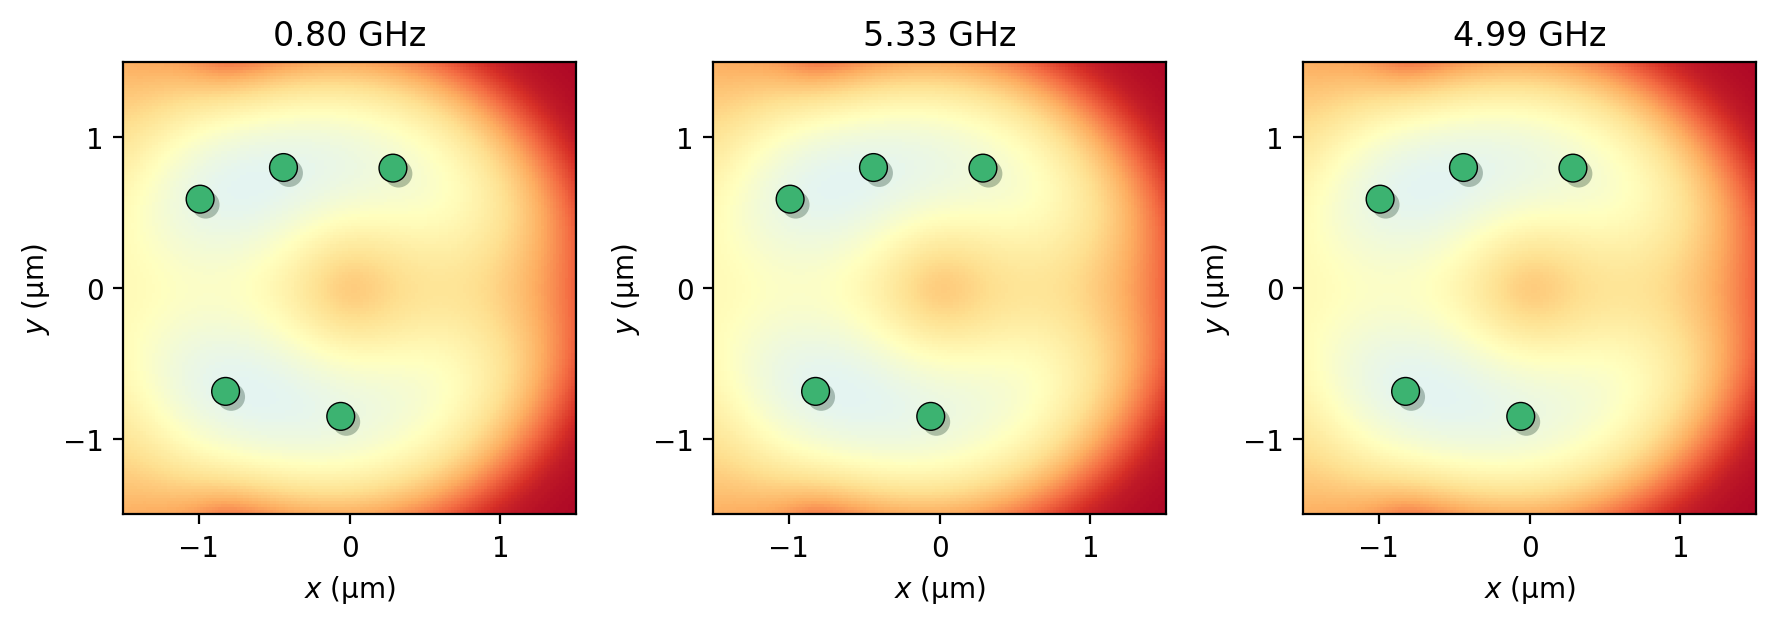

In [126]:
fig, ax = plt.subplots(1, 3, figsize=(3 * 3., 4.))

for k in range(3):
    f.plot_potential_energy(ax=ax[k], coor=[0, 0], dxdy=(3, 3), print_voltages=False)
    ax[k].set_title(f"{eigenfrequencies[k]/1e9:.2f} GHz")
    # f.plot_electron_positions(res)

    # f.plot_eigenvector(res['x'], evecs[:, 2], color='white')
    # f.plot_eigenvector(res['x'], evecs[:, 1], color='gray')

fig.tight_layout()
anim = f.animate_eigenvectors(fig, ax, eigenvector_list=evecs.T, electron_positions=res['x'],
                              amplitude=0.25e-6)

In [74]:
f.show_animation(anim)

In [ ]:
f.save_animation(anim, filepath="./single_electron_very_small_voltages.gif")

### Voltage sweep 1

on 0: Unloading 1 electrons with voltages: {'half_donut_top': np.float64(0.0), 'half_donut_bottom': np.float64(0.0), 'gate_top': -0.0, 'gate_bottom': 0.0, 'reservoir': 0.0, 'center': 0.01, 'guard': 0.0}
on 0: Converged after 3950 steps.                                               
on 0: 2.543969809377951e-12                                                     
on 0: 7.265380103094188e-14                                                     
on 0: There are 1 electrons in the dot.                                         
on 1: Unloading 1 electrons with voltages: {'half_donut_top': np.float64(0.0002), 'half_donut_bottom': np.float64(0.0002), 'gate_top': -0.0, 'gate_bottom': 0.0, 'reservoir': 0.0, 'center': 0.01, 'guard': 0.0}
on 1: Converged after 4056 steps.                                               
on 1: 5.0146330203994865e-14                                                    
on 1: 9.984818527541962e-14                                                     
on 1: There are 1 ele

(0.0, 0.02)

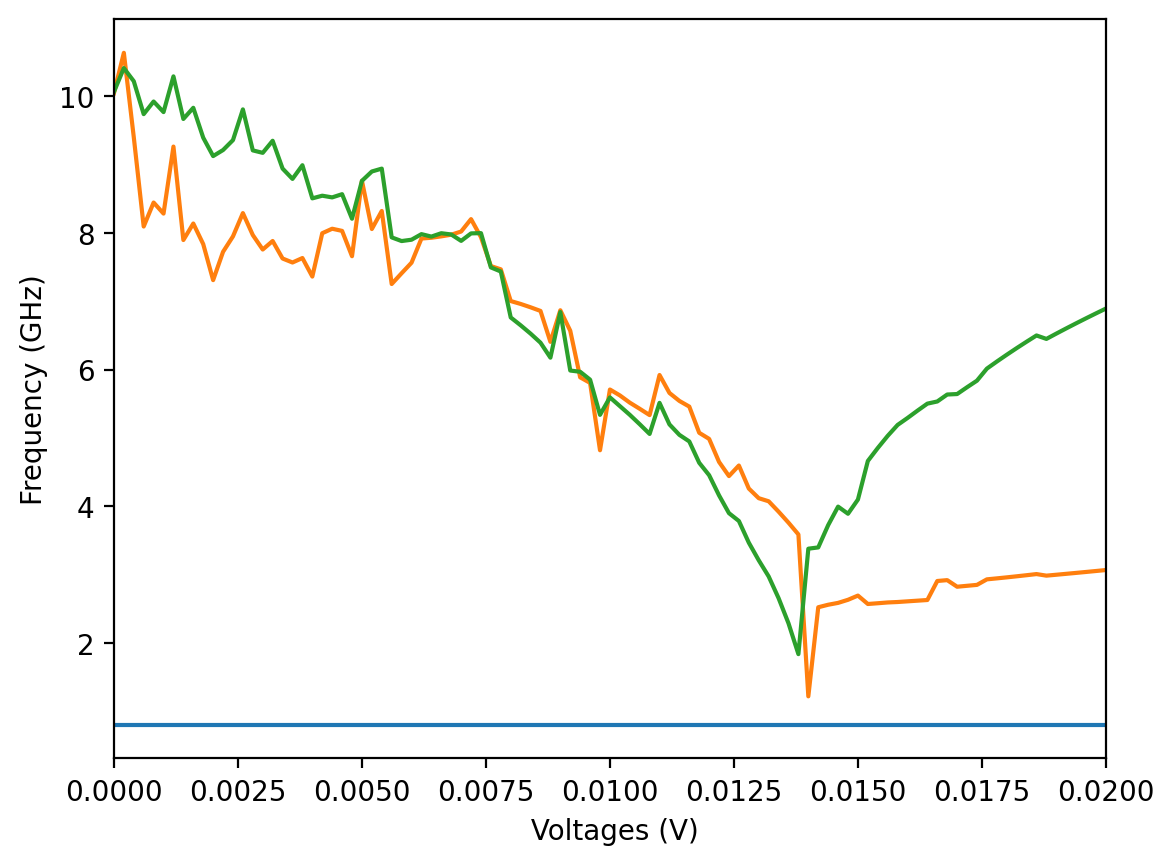

In [92]:
voltages = {
    'half_donut_top':0.00,
    'half_donut_bottom':0.00,
    'gate_top':-0.00,
    'gate_bottom':0.0,
    'reservoir':0.000,
    'center':0.01,
    'guard':0.000,
}

options = { "include_screening" : False, # Include screening of electron-electron interactions due to thin film.
           "screening_length" : np.inf, # Typically helium thickness.
           "potential_smoothing" : 1e-5, # Numerical smoothing of the splines (gets rid of some noise, can introduce artifacts)
           "remove_unbound_electrons" : False, # Removes electrons if they shot outside the solution box.
           "remove_bounds" : None, # Sets which electrons should be removed if above is True.
           "trap_annealing_steps" : [0.1] * 10, # List of annealing temperatures, length determines the number of steps
           "max_x_displacement" : 0.1e-6, # Maximum x-displacement of solved electron positions during annealing.
           "max_y_displacement" : 0.1e-6} # Maximum y-displacement of solved electron positions during annealing.

use_previous_initial_state = True # If True, use the previous equilibrium positions as initial condition for the next voltage sweep.

list_of_voltages = []
num_electrons=[]
electron_configurations=[]
sweep_voltages = np.linspace(0, 0.02, 101)

# if you put N electrons, you have 2N+1 eigenfrequencies
eigenfrequencies = np.zeros((len(sweep_voltages), 3))
plot = True

convergence_method='Physical gradient descent' # 'L-BFGS-B' or 'Physical gradient descent'


# Dimensionless rescaling
# -------------------------
# Base units (SI → dimensionless)
L0 = 1e-6                      # 1 μm in meters
E0 = qe                        # 1 eV in joules
M0 = me                        # electron mass in kg
Q0 = qe                        # elementary charge in C
T0 = L0 * np.sqrt(M0/E0)      # derived time unit

# Convert your physical timestep into dimensionless dt
dt_phys = 1e-13                # your original dt in seconds
dt = np.float64(dt_phys / T0)  # dimensionless

# Now redefine your usual Verlet coefficients in *this* dt
gamma    = np.float64(-0.01) / dt
prefactor= np.float64(1.0) / (1.0/dt**2 - gamma/dt)
A        = np.float64(2.0/dt**2 - gamma/dt)
B        = np.float64(1.0/dt**2)

max_timesteps = 500000# Maximum number of timesteps for the convergence method

N_init=1

with alive_progress.alive_bar(len(sweep_voltages), force_tty=True) as bar:
    for k, center in enumerate(sweep_voltages):

        voltages["half_donut_top"] = center
        voltages["half_donut_bottom"] = center
        


        f = FullModel(trap.dot, voltages, **options)


        f.set_rf_interpolator(rf_electrode_labels=['guard'])

        if k == 0: 
            electron_initial_positions = f.generate_initial_condition(N_init, center=(0, 0), radius=0.1e-6)
            N = N_init
        elif use_previous_initial_state: 
            electron_initial_positions = equilibrium_positions
            N = len(electron_initial_positions) // 2
        else:
            electron_initial_positions = None
            N = N_init
        
        
        if N > 0:
            print(f'Unloading {N} electrons with voltages: {voltages}')
            max_force=[]
            if convergence_method == 'L-BFGS-B':
                res = f.get_electron_positions(n_electrons=N, 
                                            electron_initial_positions=electron_initial_positions, 
                                            verbose=False, 
                                            suppress_warnings=False)
                equilibrium_positions = res['x']

    

            if convergence_method == 'Physical gradient descent':
                # Convert the *physical* positions into primed coords:
                r_old = (electron_initial_positions / L0).astype(np.float64)
                r_cur = r_old.copy()
                j = 2

                while True:
                    # compute physical gradient at r_phys = r_cur*L0
                    grad_phys = f.grad_total(r_cur * L0)          # in V/m
                    F = -(qe * grad_phys) * (L0/E0)     # dimensionless
                    max_force.append(np.max(np.abs(F)))
                     

                    # damped Verlet integration: dimensionless
                    r_next = prefactor * (F + r_cur * A - r_old * B)

                    # if j% 1000 == 0:
                    #     print('1: '+str(np.average(np.abs(r_cur*A-r_old*B))))
                    #     print('2: '+str(np.average(np.abs(F))))

                    # 4) Remove electrons out of domain in primed coords
                    x_next = r_next[::2];  y_next = r_next[1::2]
                    inside = np.logical_and.reduce((
                        x_next*L0 >= x_min, x_next*L0 <= x_max,
                        y_next*L0 >= y_min, y_next*L0 <= y_max
                    ))


                    r_next_filtered    = np.empty((2*np.sum(inside)), dtype=np.float64)
                    r_current_filtered = np.empty((2*np.sum(inside)), dtype=np.float64)

                    r_next_filtered[::2]    = x_next[inside]
                    r_next_filtered[1::2]   = y_next[inside]
                    r_current_filtered[::2] = r_cur[::2][inside]
                    r_current_filtered[1::2]= r_cur[1::2][inside]

                    # rotate for next pass
                    r_old, r_cur = r_current_filtered, r_next_filtered

                    j += 1

                    # 5) Check convergence in dimensionless force
                    if len(r_cur)==0:
                        print(f'During the convergence, no electrons left after {j} steps.')
                        break
                       
                    if np.max(np.abs(F)) < 1e-13:
                        print(f'Converged after {j} steps.')
                        r_cur = r_next_filtered
                        break


                    if j >= max_timesteps:
                        print(f'Not converged after {max_timesteps} steps.')
                        break

                # Convert *back* to physical coordinates (meters)
                equilibrium_positions = (r_cur * L0)
                print(np.linalg.norm(r_cur-r_old))
                print(max_force[-1])


            num_electrons.append(f.count_electrons_in_dot(equilibrium_positions, trap_bounds_x=(-1.5*1e-6,1.5*1e-6), trap_bounds_y=(-1.5*1e-6,1.5*1e-6))) #if trap_bounds_x,y is not specified, the default value is (-1e-6, 1e-6) for both x and y.
            print('There are '+str(num_electrons[k])+' electrons in the dot.')
            final_x, final_y = r2xy(equilibrium_positions)
            electron_configurations.append(equilibrium_positions)
            list_of_voltages.append(voltages.copy())
    

        K, M = f.setup_eom(equilibrium_positions, resonator_dict=resonator_dict)
        eigenfrequencies[k, :], evecs = f.solve_eom(K, M, sort_by_cavity_participation=True)

        bar()




plt.figure()
plt.plot(sweep_voltages, eigenfrequencies / 1e9)
plt.xlabel(" Voltages (V)")
plt.ylabel("Frequency (GHz)")
plt.xlim(np.min(sweep_voltages), np.max(sweep_voltages))

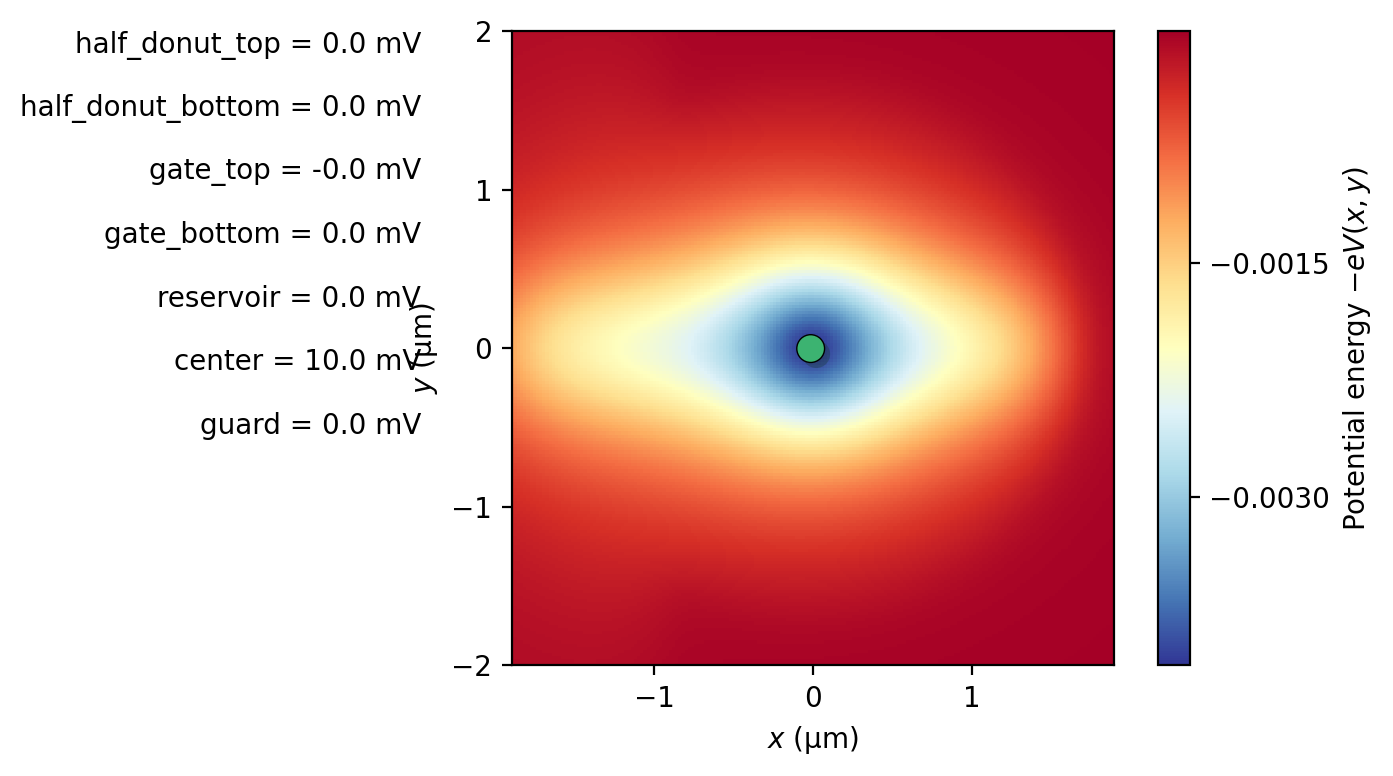

In [89]:
fig, ax = plt.subplots(figsize=(7, 4.))

anim = f.animate_voltage_sweep(fig, ax,  list_of_voltages=list_of_voltages, list_of_electron_positions=electron_configurations,
                            dxdy=(3.8, 4), frame_interval_ms=100 )
f.show_animation(anim)

(0.0, 0.02)

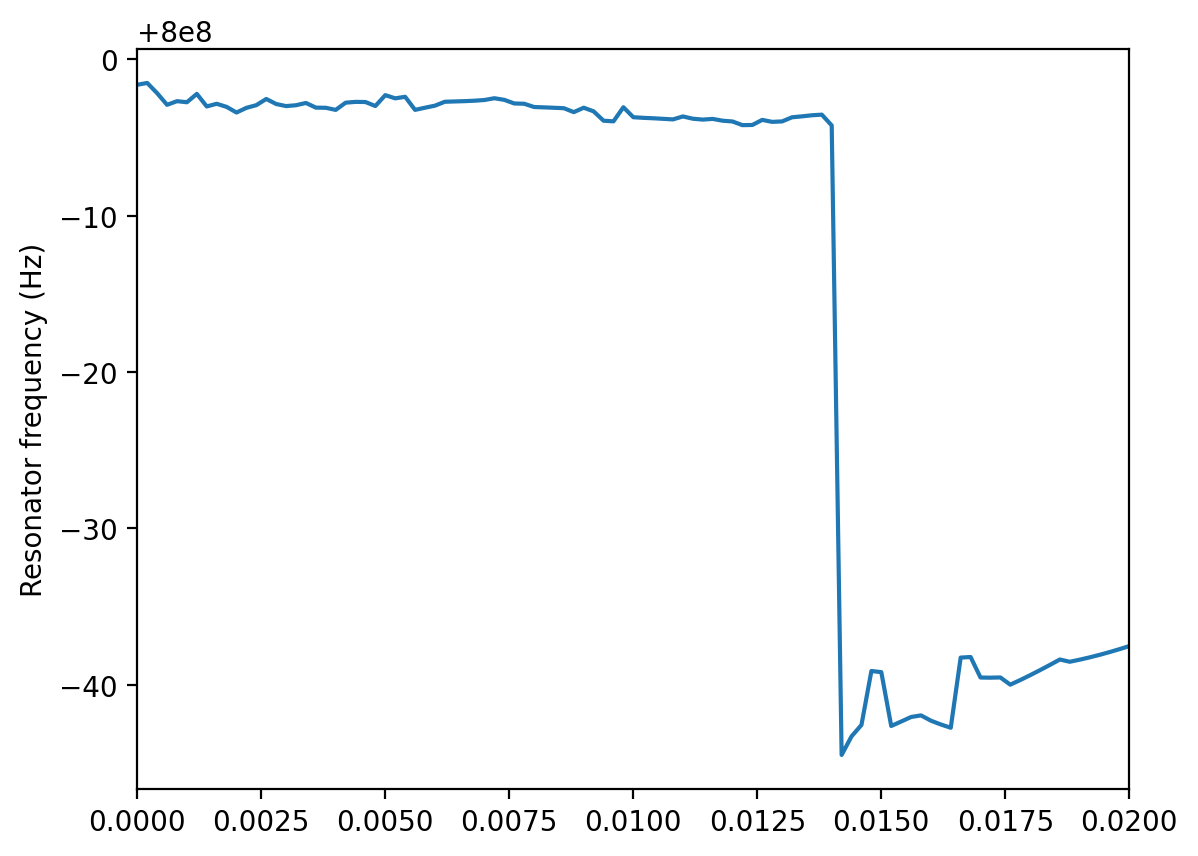

In [90]:
plt.plot(sweep_voltages, eigenfrequencies[:, 0])
plt.ylabel("Resonator frequency (Hz)")
plt.xlim(np.min(sweep_voltages), np.max(sweep_voltages))

### Voltage sweep 2

|████████████████████████████████████████| 101/101 [100%] in 12.1s (8.35/s)     


(0.0012, 0.002)

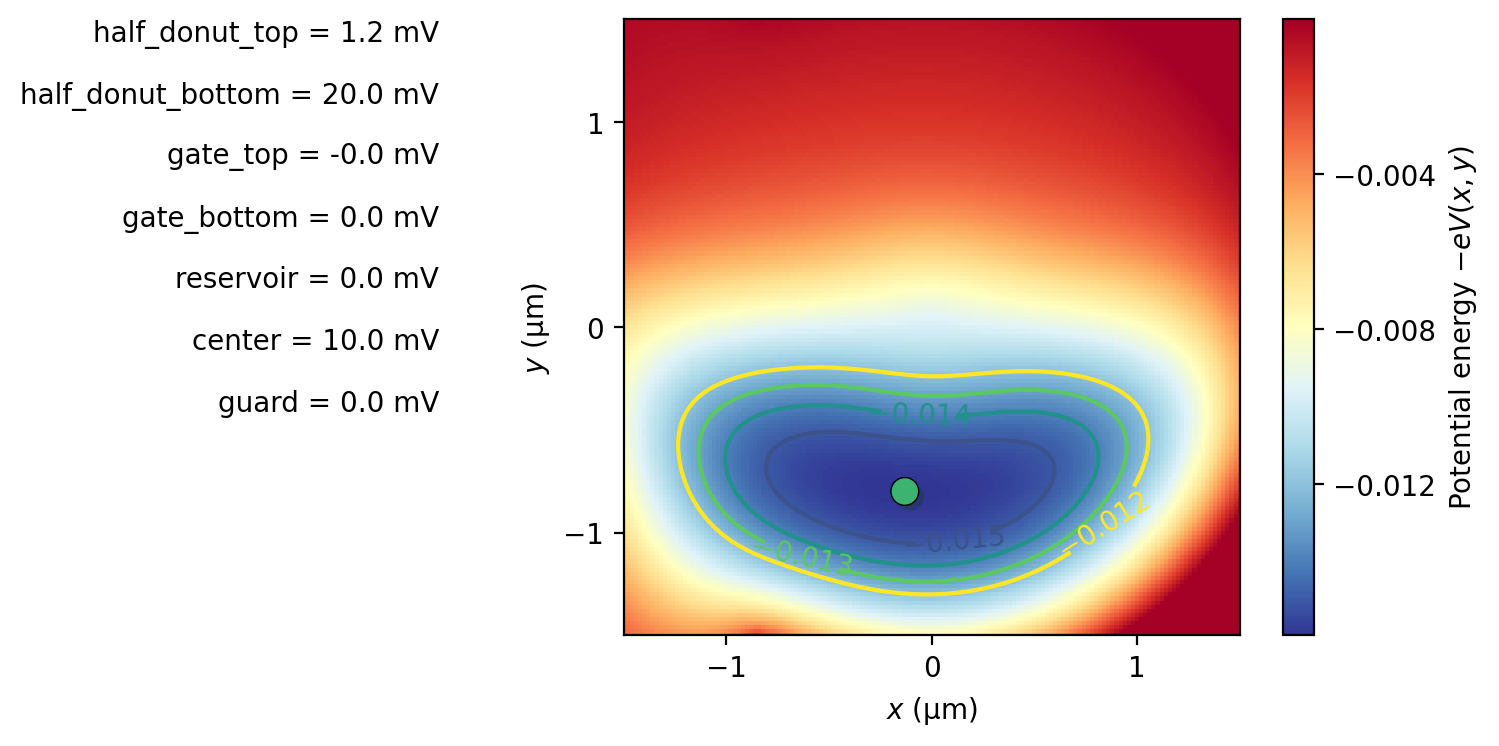

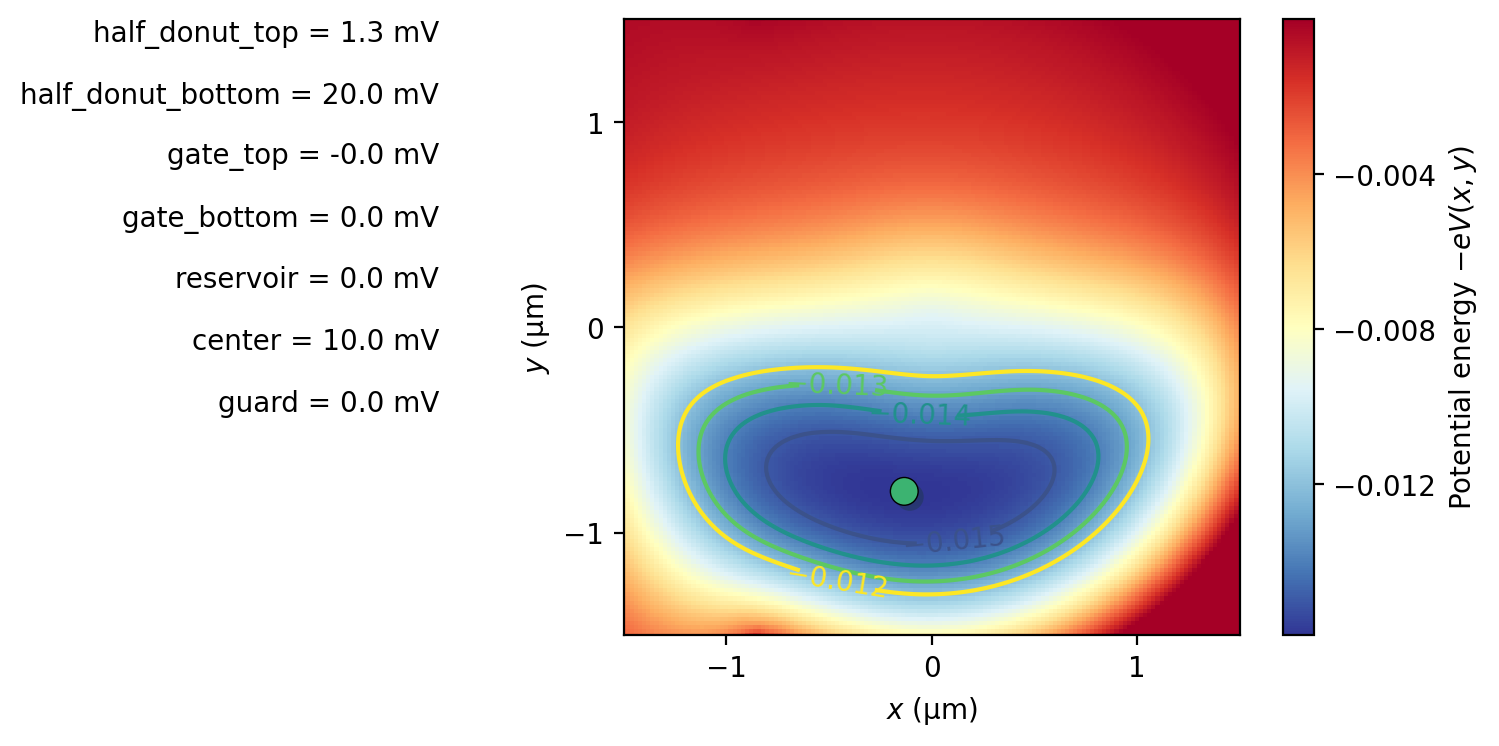

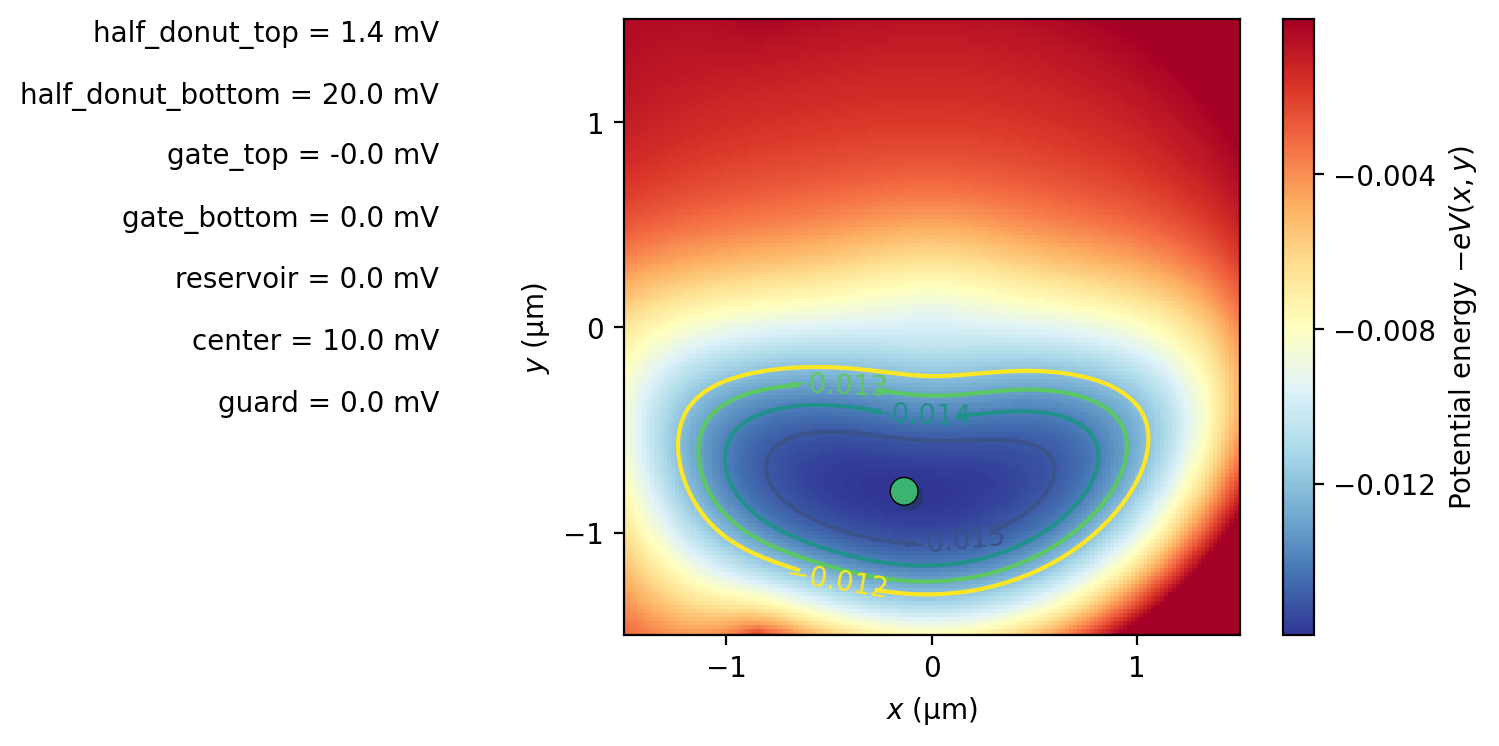

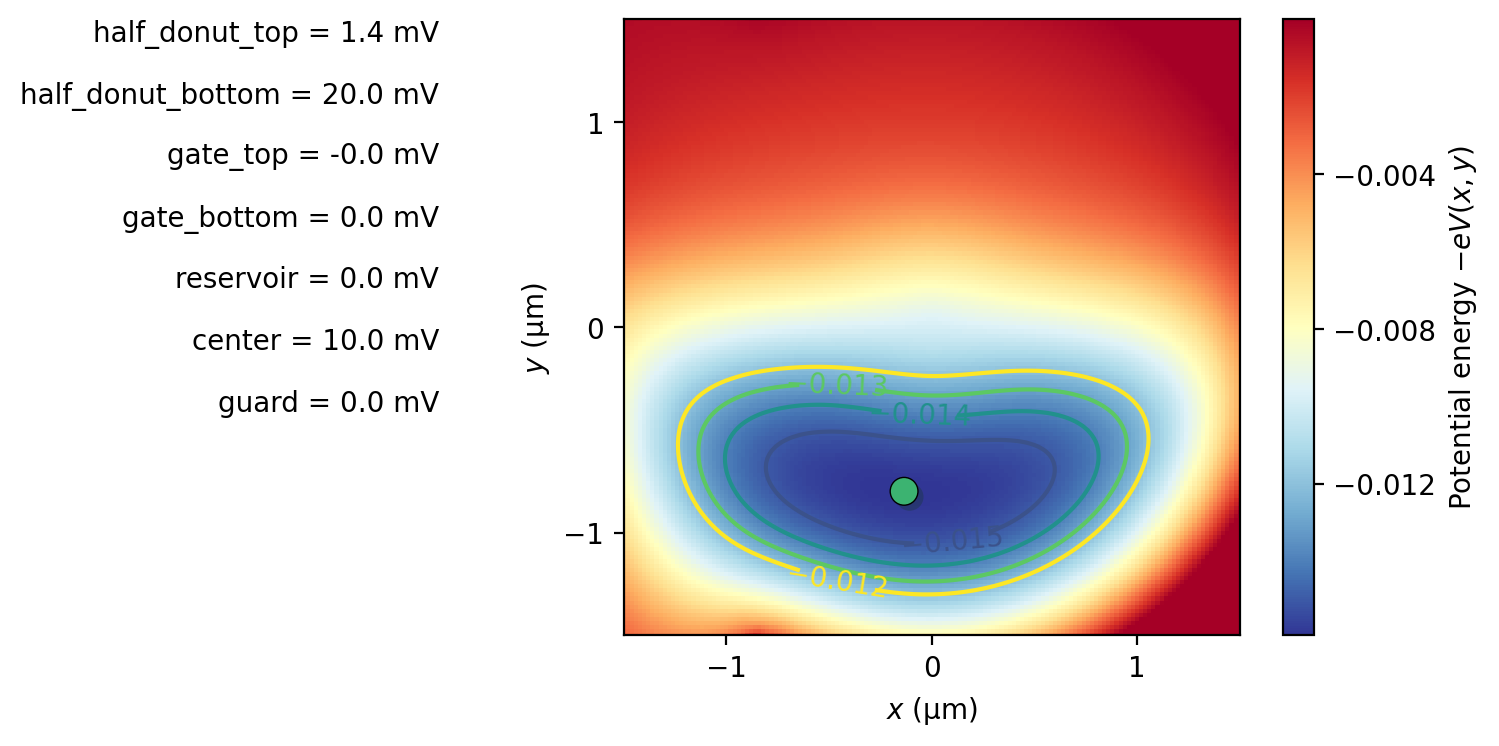

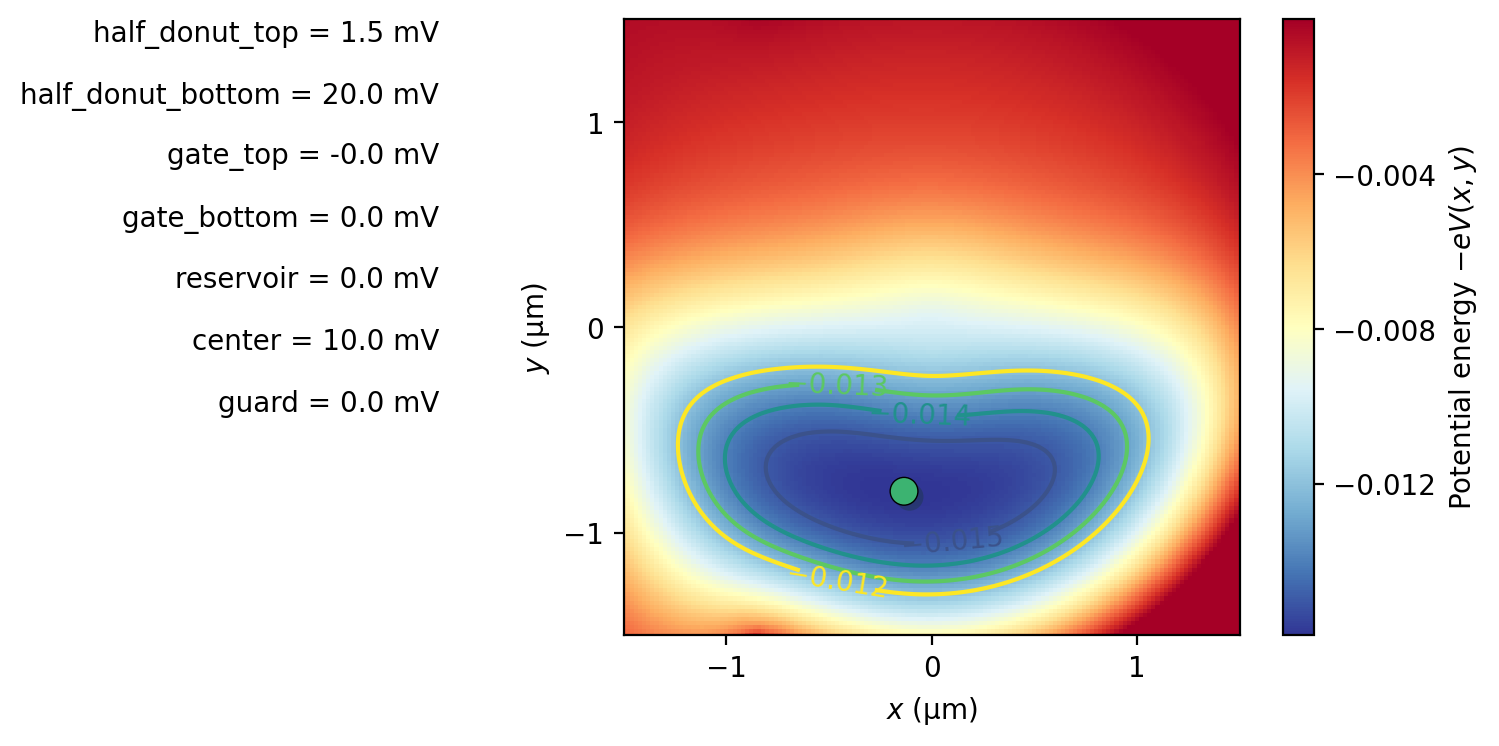

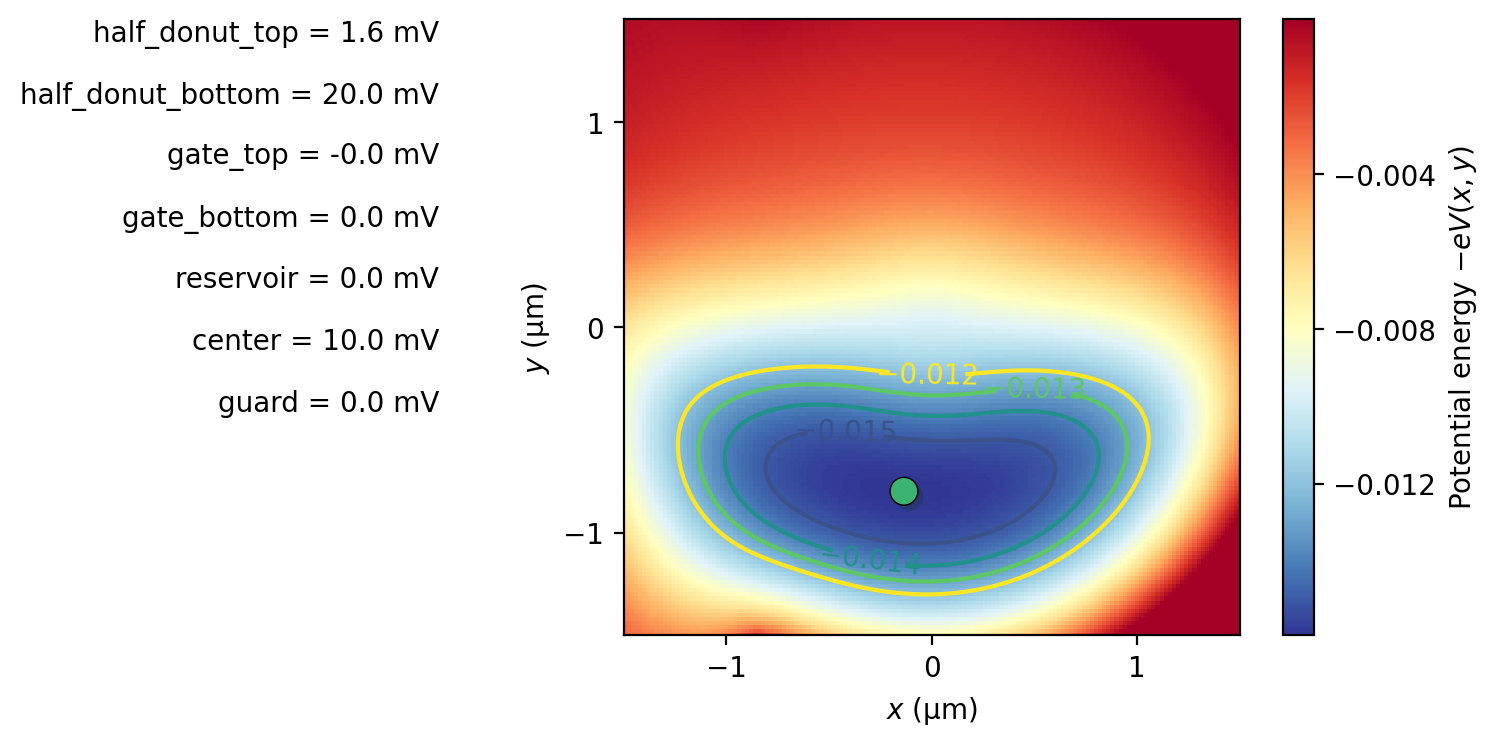

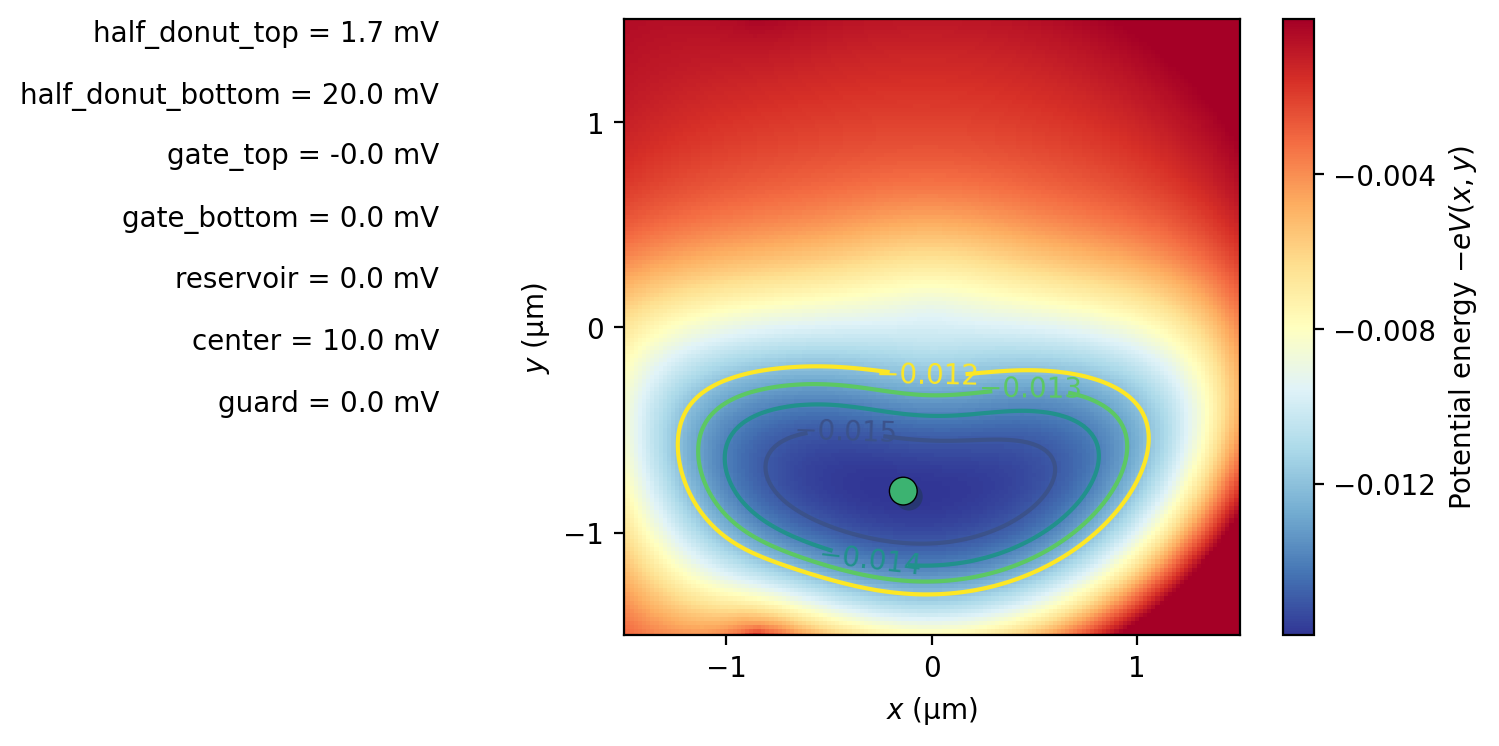

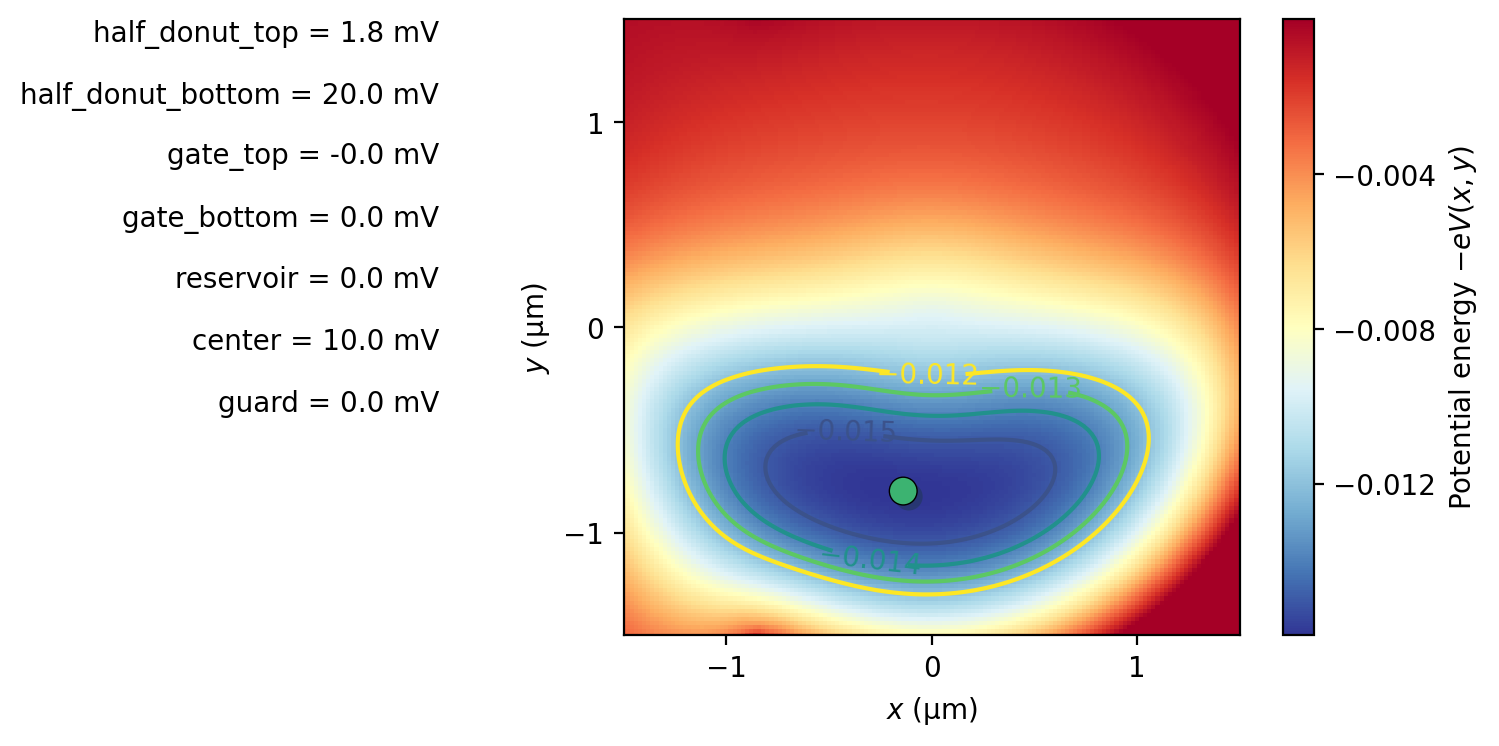

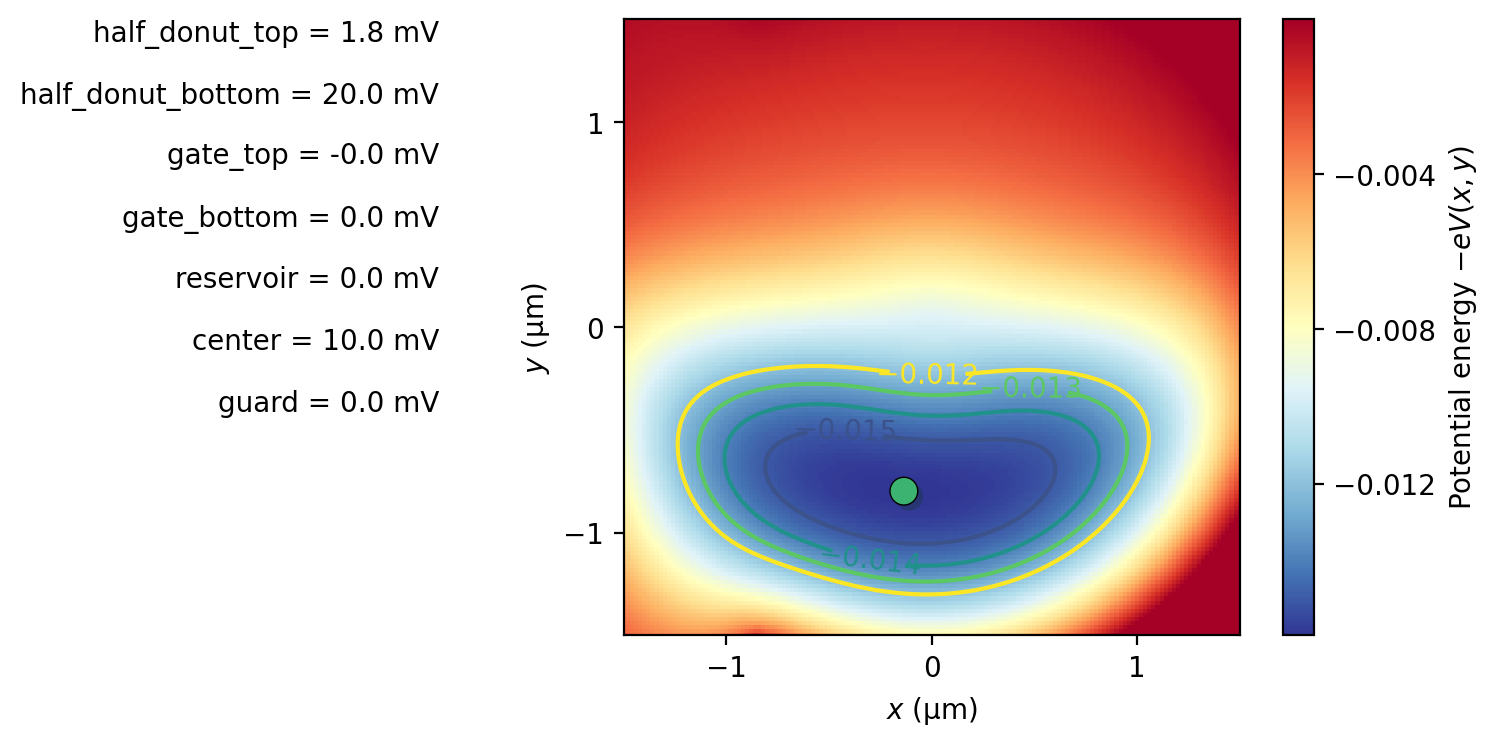

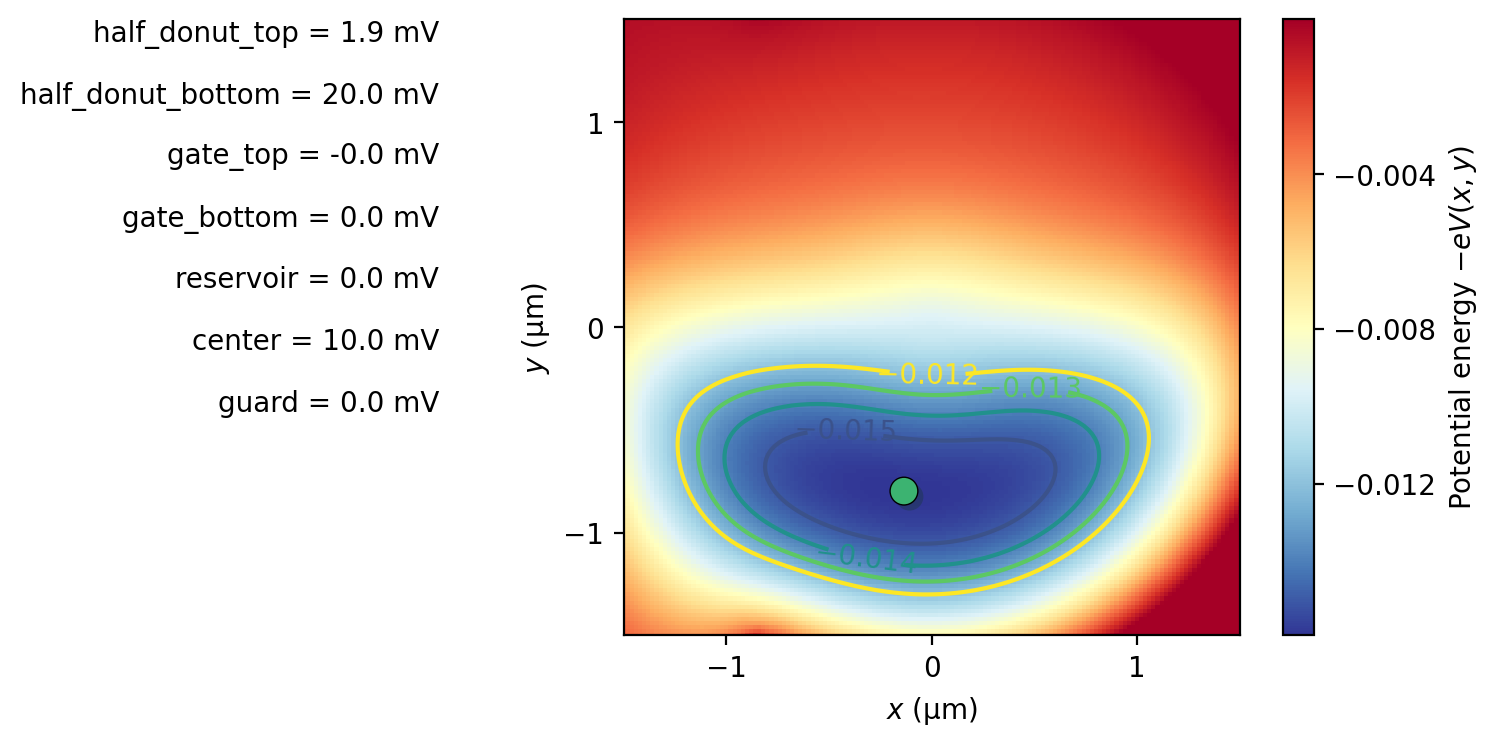

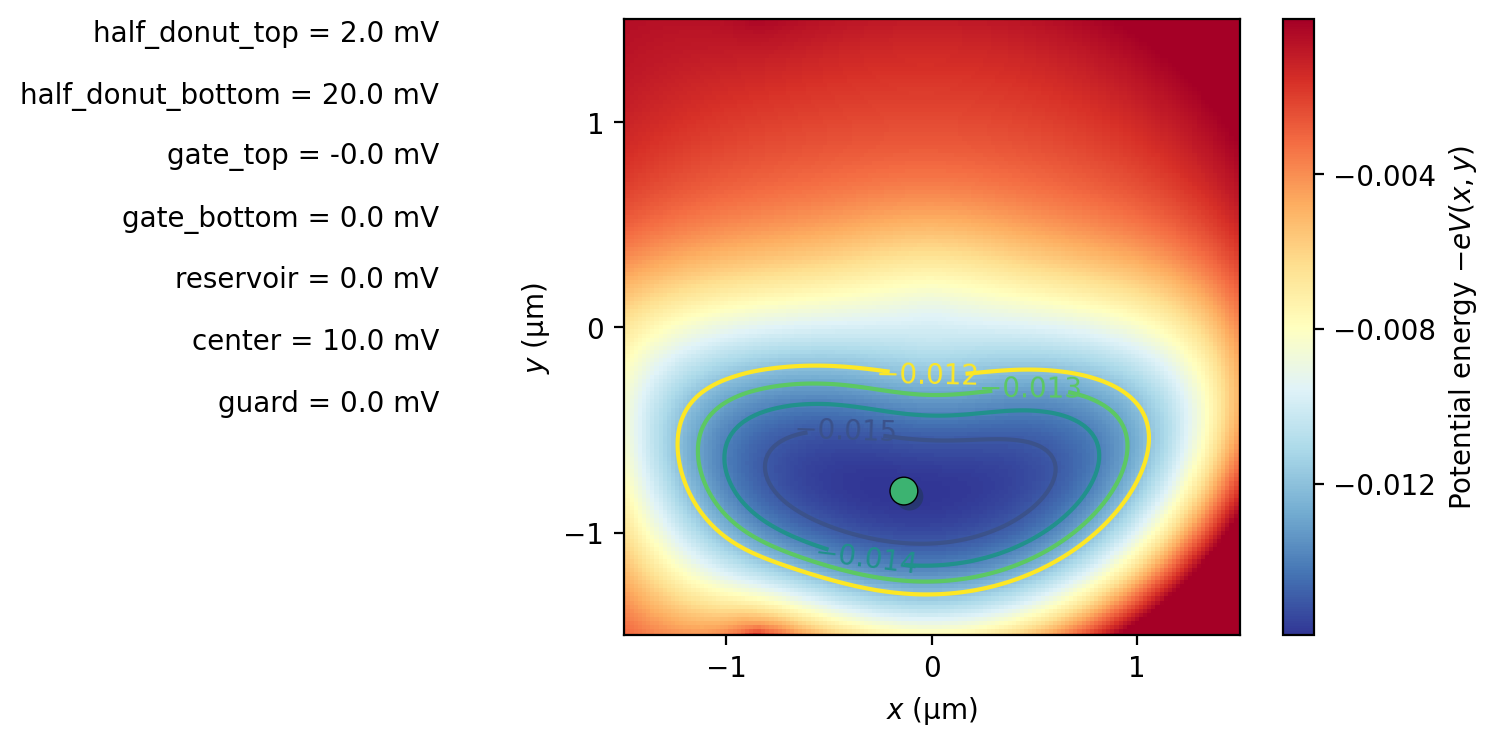

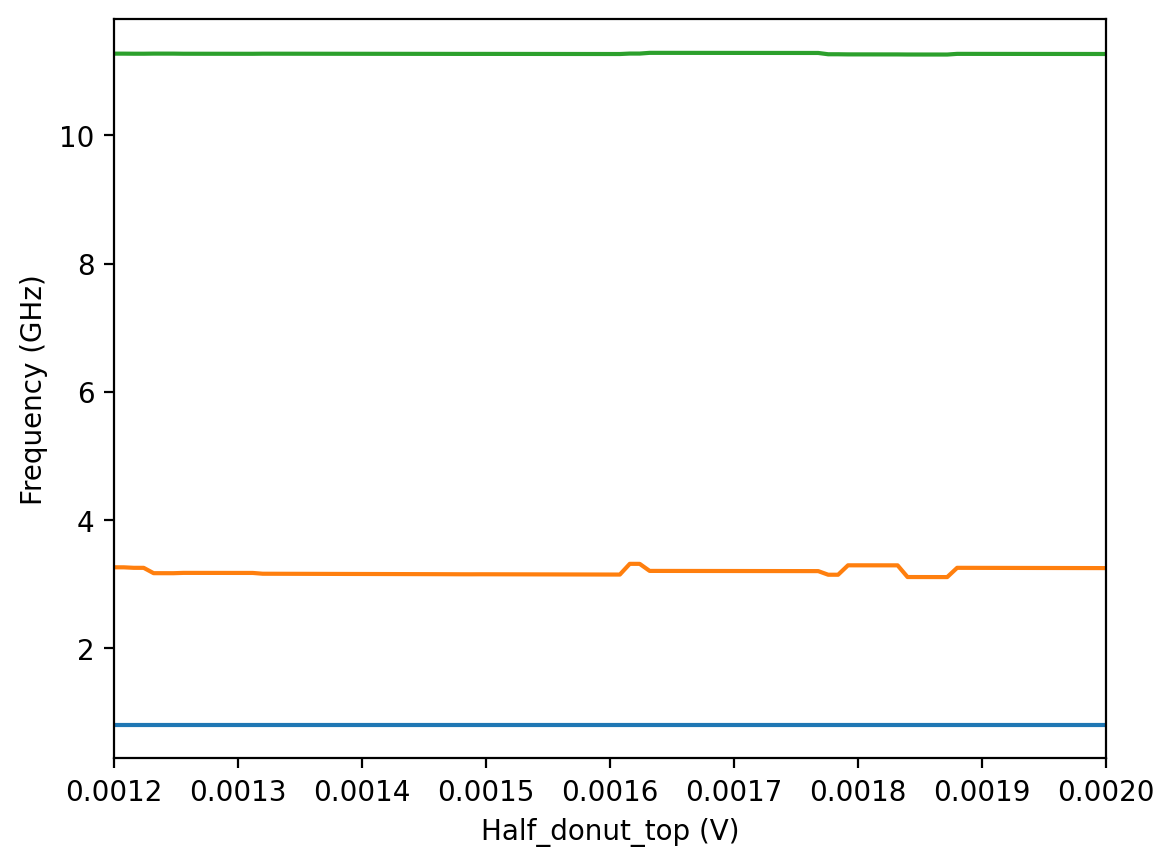

In [ ]:
sweep_voltages = np.linspace(0.0012, 0.002, 101)
eigenfrequencies = np.zeros((len(sweep_voltages), 3))
plot = True

convergence_method='L-BFGS-B' # 'L-BFGS-B' or 'Physical gradient descent'

sweep_electrode = "half_donut_top"
vi = voltages[sweep_electrode]

with alive_progress.alive_bar(len(sweep_voltages), force_tty=True) as bar:
    for k, center in enumerate(sweep_voltages):

        voltages[sweep_electrode] = center

        N = 50

        f = FullModel(trap.dot, voltages, **options)
        f.remove_unbound_electrons = False
        f.trap_annealing_steps = [0.5] * 25

        f.set_rf_interpolator(rf_electrode_labels=['guard'])


        if k == 0:
            initial_condition = f.generate_initial_condition(N)
        else:
            initial_condition = equilibrium_positions

        if convergence_method == 'L-BFGS-B':

            init_x, init_y = r2xy(initial_condition)
            res = f.get_electron_positions(n_electrons=N, electron_initial_positions=initial_condition, verbose=False, gradient_tolerance=1e-9, ftol=1e-300)
            equilibrium_positions= res['x']
            electron_configurations.append(equilibrium_positions)
            final_x, final_y = r2xy(equilibrium_positions)
            if res['status'] != 0:
                print(f"Error at k={k}, status={res['status']}")
                print(f"Error message: {res['message']}")
                continue

        
        elif convergence_method == 'Physical gradient descent':
            n_timesteps = 6000
            dt = 1e-13 
            gamma = -0.01 * me / dt # This is the damping parameter. 
            r = np.zeros((2 * N, n_timesteps+2))

            r[:, 0] = initial_condition
            r[:, 1] = initial_condition

            for j in range(2, n_timesteps+2):
                prefactor = 1 / (me / dt ** 2 - gamma / dt)
                F = - qe * f.grad_total(r[:, j-1])
                r[:, j] = prefactor * (F - r[:, j-1] * (-2 * me / dt ** 2 + gamma / dt) - r[:, j-2] * me / dt ** 2)
                
            equilibrium_positions = r[:, -1]
            electron_configurations.append(equilibrium_positions)
            final_x, final_y = r2xy(equilibrium_positions)

    


       

        # if plot and not(k%10):
        #     f.plot_potential_energy(coor=[0, 0], dxdy=(3, 3))
        #     f.plot_electron_positions(res)

        # added: resonaotor_dict
    

        K, M = f.setup_eom(equilibrium_positions, resonator_dict=resonator_dict)
        eigenfrequencies[k, :], evecs = f.solve_eom(K, M, sort_by_cavity_participation=True)

        bar()




plt.figure()
plt.plot(sweep_voltages, eigenfrequencies / 1e9)
plt.xlabel(" Voltages (V)")
plt.ylabel("Frequency (GHz)")
plt.xlim(np.min(sweep_voltages), np.max(sweep_voltages))

[7.99999977e+08 4.67440870e+09 1.08496049e+10 6.69986487e+09
 9.95985279e+09]


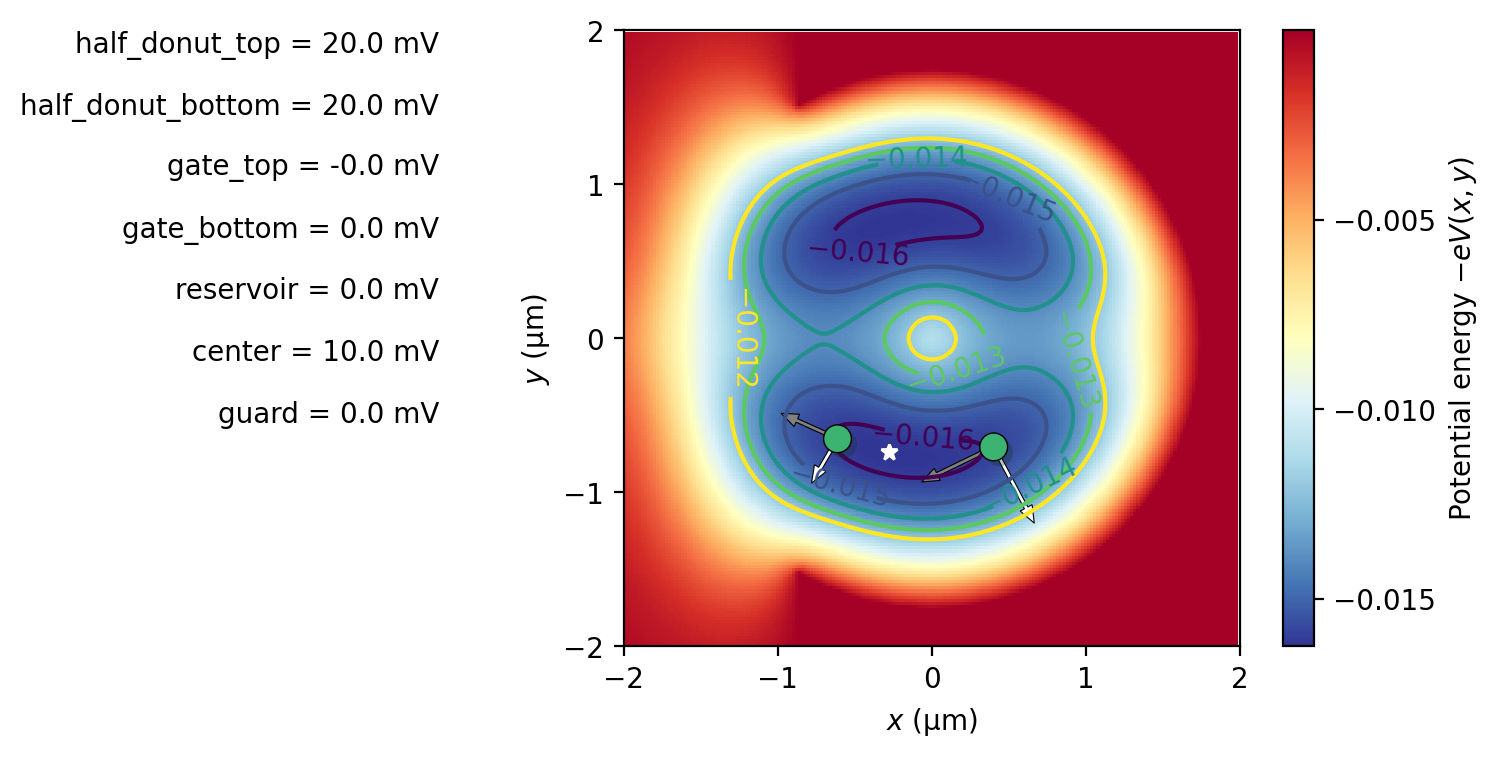

In [ ]:
N = 2

f = FullModel(trap.dot, voltages, **options)
f.remove_unbound_electrons = False
f.trap_annealing_steps = [4] * 25

f.set_rf_interpolator(rf_electrode_labels=['guard'])

initial_condition = f.generate_initial_condition(N)
init_x, init_y = r2xy(initial_condition)

res = f.get_electron_positions(n_electrons=N, electron_initial_positions=None, verbose=False)

final_x, final_y = r2xy(res['x'])

f.plot_potential_energy(coor=[0, 0], dxdy=(4, 4))
f.plot_electron_positions(res)


K, M = f.setup_eom(res['x'], resonator_dict=resonator_dict)
eigenfrequencies, evecs = f.solve_eom(K, M, sort_by_cavity_participation=True)
f.plot_eigenvector(res['x'], evecs[:, 2], color='white')
f.plot_eigenvector(res['x'], evecs[:, 1], color='gray')

print(eigenfrequencies)

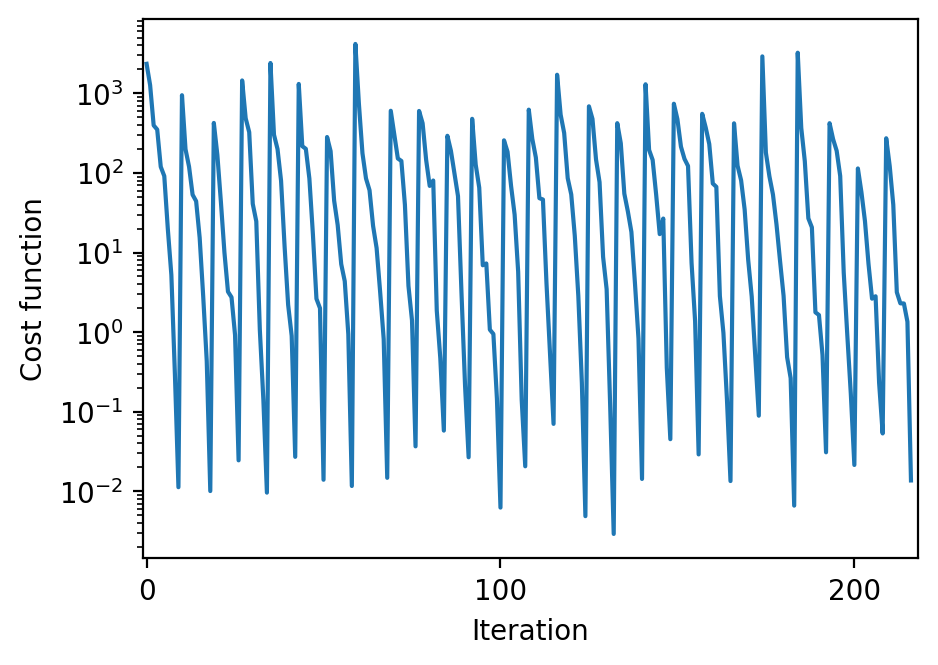

In [ ]:
f.plot_convergence()

In [ ]:
# difference between the mode most coupled to the resonator and the resonator frequency
f.get_cavity_frequency_shift(K, M)


np.float64(-23.18082332611084)

## Unloading

### Options and widgets

Potential grid: x_min=-5.00e-06, x_max=1.98e-06, y_min=-4.00e-06, y_max=3.98e-06


(-5.0, 2.0)

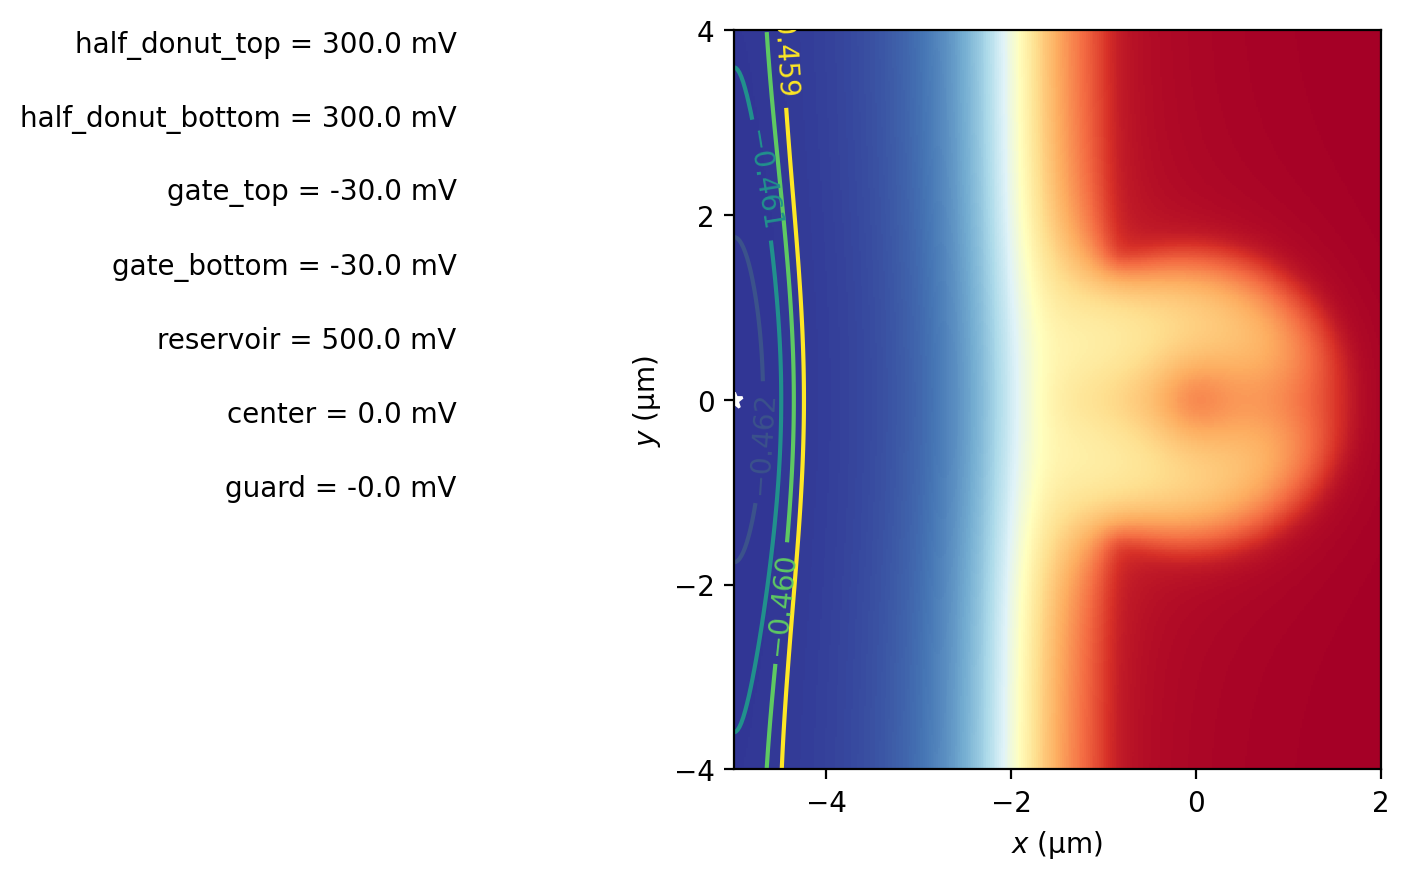

In [3]:
from quantum_electron.utils import crop_potential



left_boundary = -5 # microns

voltages = {
    'half_donut_top':0.3,
    'half_donut_bottom':0.3,
    'gate_top':-0.03,
    'gate_bottom':-0.03,
    'reservoir':0.5,
    'center':0.0,
    'guard':-0.000,
}

for electrode in voltages.keys():
    new_x, new_y, new_U = crop_potential(x=trap.dot['xlist'], y=trap.dot['ylist'], U=trap.dot[electrode], 
                                         xrange=(left_boundary, 2), yrange=(-4, 4))
    
    trap.dot[electrode] = new_U

trap.dot['xlist'] = new_x 
trap.dot['ylist'] = new_y
 
x_min= np.min(trap.dot['xlist'])*1e-6
x_max= np.max(trap.dot['xlist'])*1e-6
y_min= np.min(trap.dot['ylist'])*1e-6
y_max= np.max(trap.dot['ylist'])*1e-6
print(f"Potential grid: x_min={x_min:.2e}, x_max={x_max:.2e}, y_min={y_min:.2e}, y_max={y_max:.2e}")




options = { "include_screening" : False, # Include screening of electron-electron interactions due to thin film.
           "screening_length" : np.inf, # Typically helium thickness.
           "potential_smoothing" : 1e-5, # Numerical smoothing of the splines (gets rid of some noise, can introduce artifacts)
           "remove_unbound_electrons" : False, # Removes electrons if they shot outside the solution box.
           "remove_bounds" : None, # Sets which electrons should be removed if above is True.
           "trap_annealing_steps" : [0.1] * 10, # List of annealing temperatures, length determines the number of steps
           "max_x_displacement" : 0.1e-6, # Maximum x-displacement of solved electron positions during annealing.
           "max_y_displacement" : 0.1e-6} # Maximum y-displacement of solved electron positions during annealing.



fig, ax = plt.subplots()
fm = FullModel(trap.dot, voltages, **options)
fm.plot_potential_energy(ax=ax, coor=[0,0], dxdy=(10, 8))
ax.set_xlim(-5, 2)

In [4]:

Vrms = 140e-9
f0 = 0.800e9

Z = 2 / 1.055e-34 * (Vrms / (2 * np.pi * f0)) ** 2

resonator_dict = {"f0" : f0, # Resonance frequency for the resonator (only used for solving motional frequencies)
           "Z0" : Z }# Resonator impedance (only used for solving motional frequencies)



### Unloading the dot

In [ ]:
# cavity_freqs_list = []
# electron_modef_list=[]
# voltages_list = []


# for f0 in [0.120945e9, 0.400e9, 0.600e9, 0.800e9]:


voltages = {
    'half_donut_top':0.05,
    'half_donut_bottom':0.05,
    'gate_top':-0.03,
    'gate_bottom':-0.03,
    'reservoir':0.05,
    'center':0.0,
    'guard':0.0,
}

random.seed()

use_previous_initial_state = True
unload_voltages = np.linspace(-0.03, 0.0193, 200) # for the gates
# unload_voltages_forward = np.linspace(0.007, 0.0005, 100) # for the reservoir
# unload_voltages_backward = unload_voltages_forward[::-1][1:]
# unload_voltages=np.concatenate((unload_voltages_forward, unload_voltages_backward))

# Initial number of electrons to start with
N_init = 5

temperature = 1.2 # Only important for calculation of the Gamma = Ec / Ek

# Keep track of some variables
energies = np.zeros(len(unload_voltages))
num_electrons = np.zeros(len(unload_voltages))
cavity_freqs=[]
electron_configurations = []
list_of_voltages = []
num_electrons_chgd_disk = np.zeros(len(unload_voltages))
num_electrons_par_cap = np.zeros(len(unload_voltages))
densities = np.zeros(len(unload_voltages))
gamma_param = np.zeros(len(unload_voltages))
disc_capacitances = np.zeros(len(unload_voltages))
electron_modef = []
trap_depth = np.zeros(len(unload_voltages))  
# Choose the convergence method for the calculation of the electron positions at equilibrium.
convergence_method = 'Physical gradient descent' # 'L-BFGS-B' or 'Physical gradient descent'



# Dimensionless rescaling
# Base units (SI → dimensionless)
L0 = 1e-6                      # 1 μm in meters
E0 = qe                        # 1 eV in joules
M0 = me                        # electron mass in kg
Q0 = qe                        # elementary charge in C
T0 = L0 * np.sqrt(M0/E0)      # derived time unit

# Convert physical timestep into dimensionless dt
dt_phys = 1e-13                # your original dt in seconds
dt = np.float64(dt_phys / T0)  # dimensionless

# redefine usual Verlet coefficients
gamma    = np.float64(-0.01) / dt
prefactor= np.float64(1.0) / (1.0/dt**2 - gamma/dt)
A        = np.float64(2.0/dt**2 - gamma/dt)
B        = np.float64(1.0/dt**2)

max_timesteps = 4000000 # Maximum number of timesteps for the convergence method

with alive_progress.alive_bar(len(unload_voltages), force_tty=True) as bar:
    for k, unload in enumerate(unload_voltages):

        # Here you can change how to unload the electrons (which electrodes to sweep)
        # voltages['center'] = unload
        # voltages['half_donut_top'] = unload
        # voltages['half_donut_bottom'] = unload
    
        voltages['gate_top'] = unload
        voltages['gate_bottom'] = unload
        # voltages['reservoir']=unload
        
        
        
        f = FullModel(trap.dot, voltages, **options)

        f.set_rf_interpolator(rf_electrode_labels=['guard'])
        
        if k == 0: 
            electron_initial_positions = f.generate_initial_condition(N_init, center=(0, 0), radius=0.1e-6)
            N = N_init
        elif use_previous_initial_state: 
            electron_initial_positions = equilibrium_positions
            N = len(electron_initial_positions) // 2
        else:
            electron_initial_positions = None
            N = N_init
        
        
        if N > 0:
            print(f'Unloading {N} electrons with voltages: {voltages}')
            max_force=[]
            if convergence_method == 'L-BFGS-B':
                res = f.get_electron_positions(n_electrons=N, 
                                            electron_initial_positions=electron_initial_positions, 
                                            verbose=False, 
                                            suppress_warnings=False)
                equilibrium_positions = res['x']

    

            if convergence_method == 'Physical gradient descent':
                # Convert the *physical* positions into primed coords:
                r_old = (electron_initial_positions / L0).astype(np.float64)
                r_cur = r_old.copy()
                j = 2

                while True:
                    # compute physical gradient at r_phys = r_cur*L0
                    grad_phys = f.grad_total(r_cur * L0)          # in V/m
                    F = -(qe * grad_phys) * (L0/E0)     # dimensionless
                    max_force.append(np.max(np.abs(F)))
                    

                    # damped Verlet integration: dimensionless
                    r_next = prefactor * (F + r_cur * A - r_old * B)

                    # if j% 1000 == 0:
                    #     print('1: '+str(np.average(np.abs(r_cur*A-r_old*B))))
                    #     print('2: '+str(np.average(np.abs(F))))

                    # 4) Remove electrons out of domain in primed coords
                    x_next = r_next[::2];  y_next = r_next[1::2]
                    inside = np.logical_and.reduce((
                        x_next*L0 >= x_min, x_next*L0 <= x_max,
                        y_next*L0 >= y_min, y_next*L0 <= y_max
                    ))


                    r_next_filtered    = np.empty((2*np.sum(inside)), dtype=np.float64)
                    r_current_filtered = np.empty((2*np.sum(inside)), dtype=np.float64)

                    r_next_filtered[::2]    = x_next[inside]
                    r_next_filtered[1::2]   = y_next[inside]
                    r_current_filtered[::2] = r_cur[::2][inside]
                    r_current_filtered[1::2]= r_cur[1::2][inside]

                    # rotate for next pass
                    r_old, r_cur = r_current_filtered, r_next_filtered
                    j += 1

                    # 5) Check convergence in dimensionless force
                    if len(r_cur)==0:
                        print(f'During the convergence, no electrons left after {j} steps.')
                        break
                    
                    if np.max(np.abs(F)) < 1e-12:
                        print(f'Converged after {j} steps.')
                        r_cur = r_next_filtered
                        break

                    if j >= max_timesteps:
                        print(f'Not converged after {max_timesteps} steps.')
                        break

                # Convert *back* to physical coordinates (meters)
                equilibrium_positions = (r_cur * L0)
                


            num_electrons[k] = f.count_electrons_in_dot(equilibrium_positions, trap_bounds_x=(-1.5*1e-6,1.5*1e-6), trap_bounds_y=(-1.5*1e-6,1.5*1e-6)) #if trap_bounds_x,y is not specified, the default value is (-1e-6, 1e-6) for both x and y.
            print('There are '+str(num_electrons[k])+' electrons in the dot.')
            print(f'The maximum distance between between two iterations is {np.max(np.abs(r_cur - r_old) * 1e12):.2f} pm.')
            print(f'Max force: {max_force[-1]}')
            final_x, final_y = r2xy(equilibrium_positions)
            electron_configurations.append(equilibrium_positions)
            
            

        if N==0:
            print(f'During the voltage sweep, no electrons left after {k} steps.')
            break
        
        K, M = f.setup_eom(equilibrium_positions, resonator_dict)
        eigenfrequencies, evecs = f.solve_eom(K, M, sort_by_cavity_participation=True)
        
        if len(equilibrium_positions) > 1:
            electron_modef.append(eigenfrequencies[1])
            cavity_freqs.append(eigenfrequencies[0])
            list_of_voltages.append(voltages.copy())
            print('The cavity frequency is: ', eigenfrequencies[0])
        else:
            electron_modef.append(np.nan)  

        
        bar()
                
    # cavity_freqs_list.append(cavity_freqs)
    # electron_modef_list.append(electron_modef)


on 0: Unloading 5 electrons with voltages: {'half_donut_top': 0.05, 'half_donut_bottom': 0.05, 'gate_top': np.float64(-0.03), 'gate_bottom': np.float64(-0.03), 'reservoir': 0.05, 'center': 0.0, 'guard': 0.0}
on 0: Converged after 20281 steps.                                              
on 0: There are 5.0 electrons in the dot.                                       
on 0: The maximum distance between between two iterations is 0.20 pm.           
on 0: Max force: 9.998880159400868e-13                                          
on 0: The cavity frequency is:  799999934.4476813                               
on 1: Unloading 5 electrons with voltages: {'half_donut_top': 0.05, 'half_donut_bottom': 0.05, 'gate_top': np.float64(-0.029752261306532662), 'gate_bottom': np.float64(-0.029752261306532662), 'reservoir': 0.05, 'center': 0.0, 'guard': 0.0}
on 1: Converged after 14432 steps.                                              
on 1: There are 5.0 electrons in the dot.                         

In [8]:
f0_list = [0.120945e9, 0.400e9, 0.600e9, 0.800e9]

In [ ]:
print(electron_initial_positions)
print(equilibrium_positions)
print(r_cur)
print((electron_initial_positions / L0).astype(np.float64))  
print(N)

[-4.52320000e-06  1.57975653e-07]
[-4.52320000e-06  1.57975653e-07]
[]
[-4.5232      0.15797565]
1


### Animates the voltage sweep

200
200


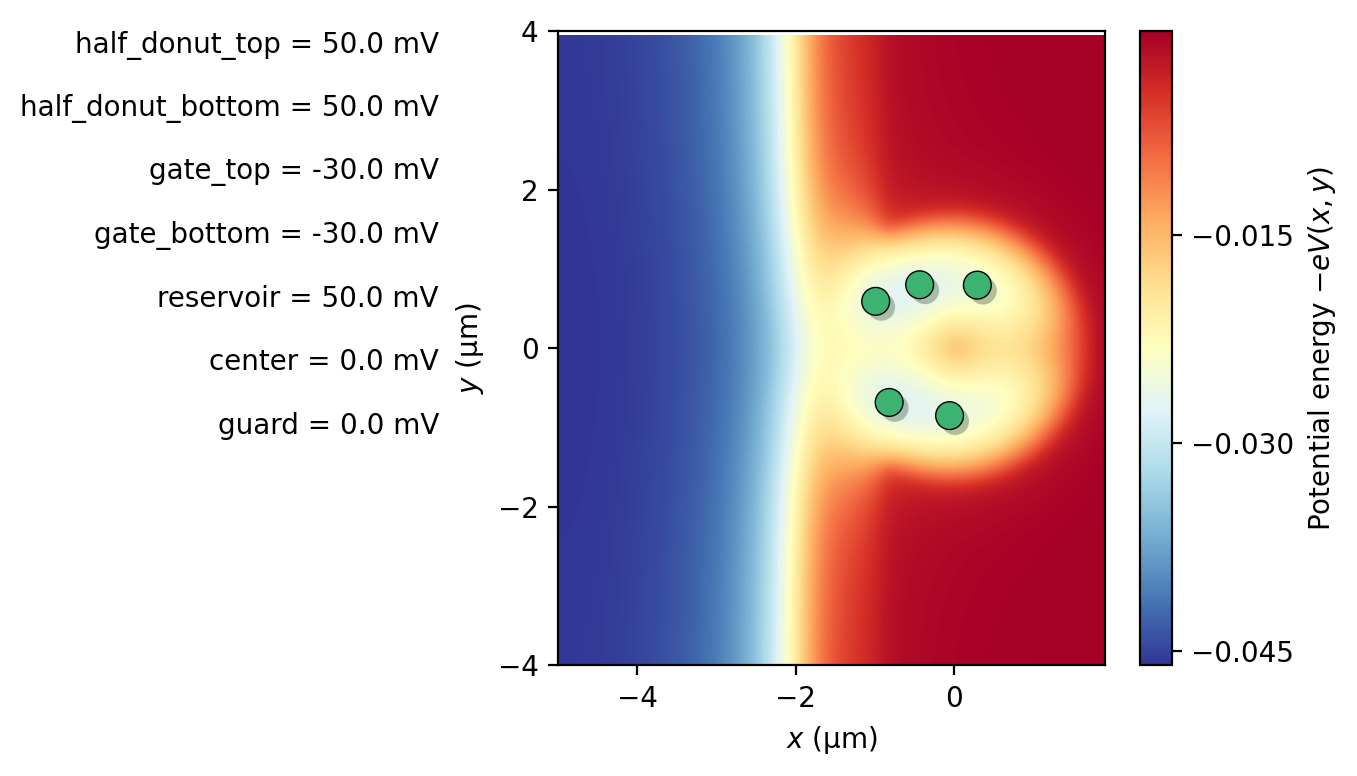

In [10]:
fig, ax = plt.subplots(figsize=(7, 4.))
print(len(list_of_voltages))
print(len(electron_configurations))
anim = f.animate_voltage_sweep(fig, ax,  list_of_voltages=list_of_voltages, list_of_electron_positions=electron_configurations,
                            dxdy=(10, 8), frame_interval_ms=200 )
ax.set_xlim(-5, 1.9)
f.show_animation(anim)

### Plot the number of electrons and the frequency shifts

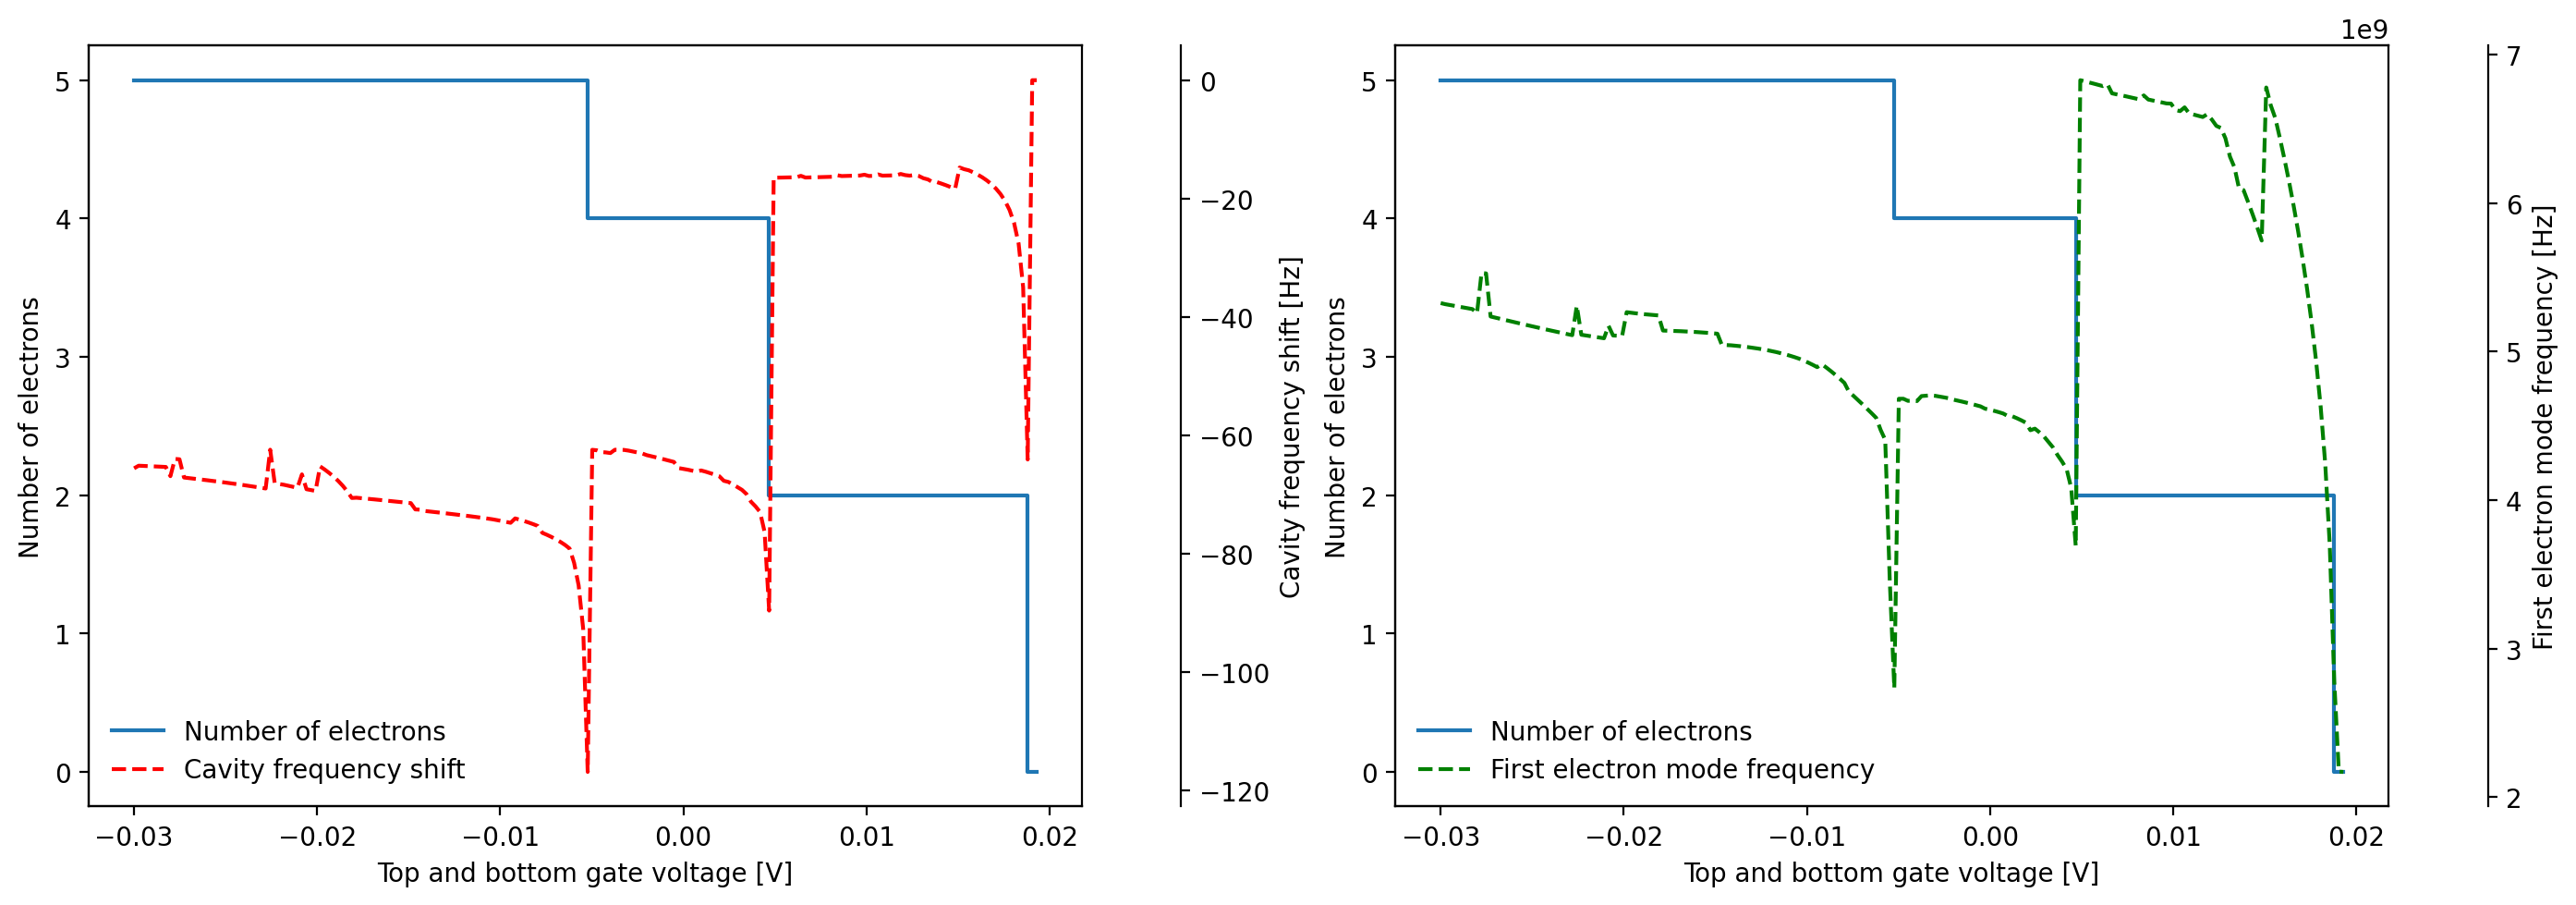

In [6]:
%matplotlib inline


fig, (ax1, ax3) = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

# ==== Left subplot ====
ax1.step(unload_voltages, num_electrons, label="Number of electrons", color='tab:blue')
ax1.set_xlabel("Top and bottom gate voltage [V]")
ax1.set_ylabel("Number of electrons")

ax2 = ax1.twinx()
ax2.plot(unload_voltages, cavity_freqs - f0*np.ones(len(cavity_freqs)), 'r--', label="Cavity frequency shift")
ax2.set_ylabel("Cavity frequency shift [Hz]")
ax2.spines["right"].set_position(("axes", 1.1))

# Legend for left subplot at bottom left
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower left', frameon=False)


# ==== Right subplot ====
ax3.step(unload_voltages, num_electrons, label="Number of electrons", color='tab:blue')
ax3.set_xlabel("Top and bottom gate voltage [V]")
ax3.set_ylabel("Number of electrons")

ax4 = ax3.twinx()
ax4.plot(unload_voltages, electron_modef, 'g--', label="First electron mode frequency")
ax4.set_ylabel("First electron mode frequency [Hz]")
ax4.spines["right"].set_position(("axes", 1.1))

# Legend for right subplot at bottom left
lines3, labels3 = ax3.get_legend_handles_labels()
lines4, labels4 = ax4.get_legend_handles_labels()
ax3.legend(lines3 + lines4, labels3 + labels4, loc='lower left', frameon=False)

plt.tight_layout()
plt.show()

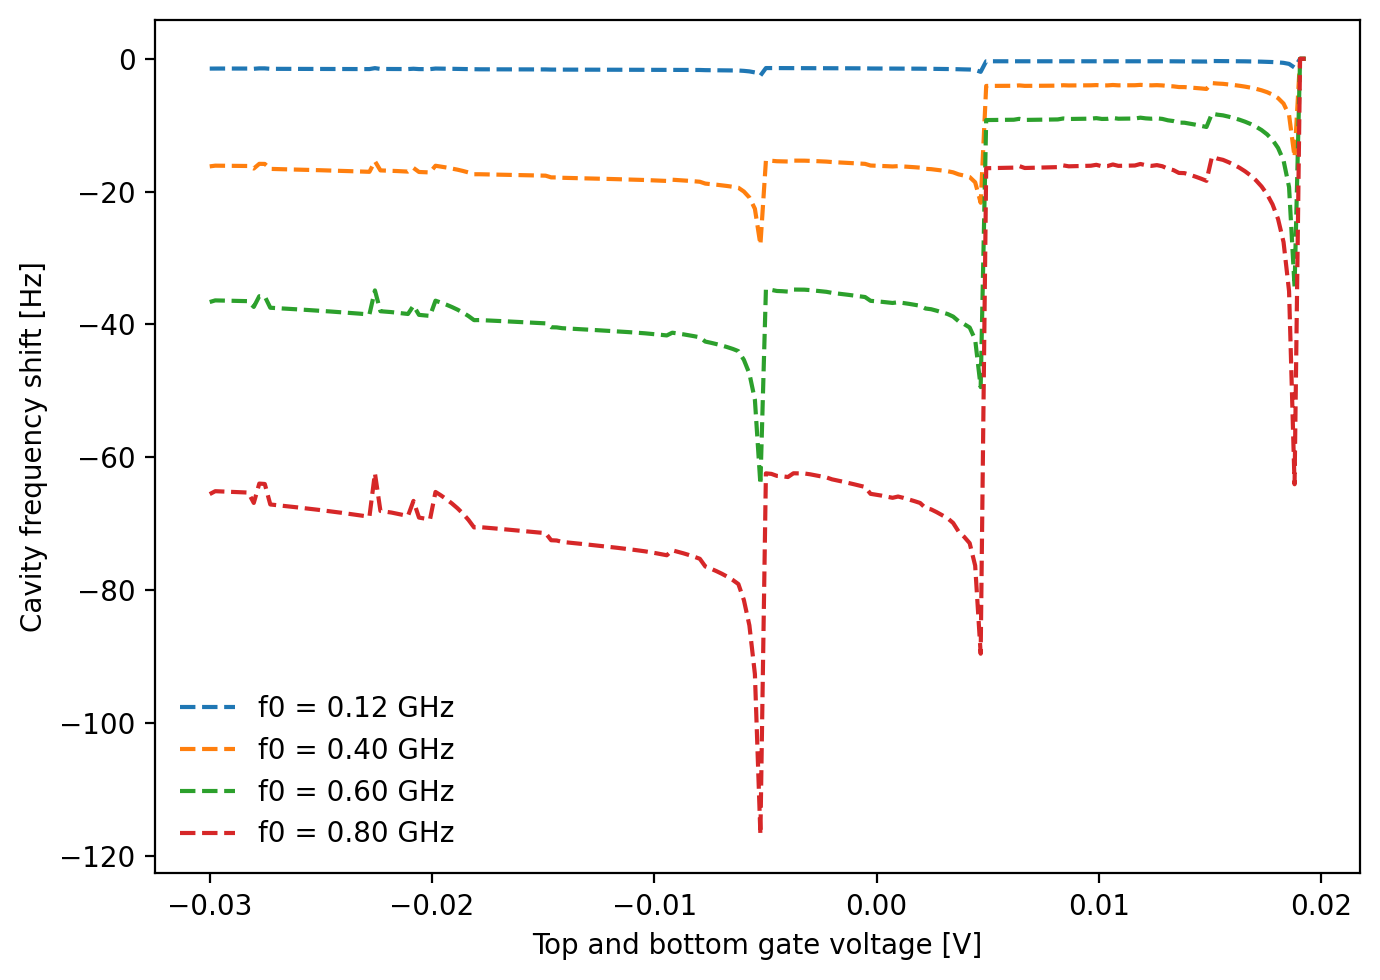

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))
cavity_freqs_list = np.array(cavity_freqs_list)

# Tracer les shifts de fréquence pour chaque courbe
for i, cavity_freqs in enumerate(cavity_freqs_list):
# for i in range(len(f0_list)):
    label = f"f0 = {f0_list[i]*1e-9:.2f} GHz"
    ax.plot(unload_voltages, cavity_freqs - f0_list[i]*np.ones(len(cavity_freqs)), '--', label=label)

# Axe et titre
ax.set_xlabel("Top and bottom gate voltage [V]")
ax.set_ylabel("Cavity frequency shift [Hz]")
ax.legend(loc='lower left', frameon=False)

plt.tight_layout()
plt.show()
